In [1]:
# ═══════════════════════════════════════════════════════════
# CELL 1 — Mount Drive + verify folder structure
# ═══════════════════════════════════════════════════════════
from google.colab import drive
import os
drive.mount('/content/drive')

BASE   = '/content/drive/MyDrive/drug_project'
DATA   = f'{BASE}/data'
OUT    = f'{BASE}/outputs'
os.makedirs(OUT, exist_ok=True)

# Check which data files are present
files = {
    'kg.csv'                                  : 'PrimeKG knowledge graph',
    'CTD_curated_chemicals_diseases.csv.gz'              : 'CTD chemicals-diseases',
    'CTD_curated_genes_diseases.csv.gz'                  : 'CTD genes-diseases',
    'full database.xml'          : 'DrugBank full XML  ← DDI extracted here',
    'structure links.csv'       : 'DrugBank SMILES (Structure External Links)',
    'drug links.csv'        : 'DrugBank External Drug Links (ID mappings)',
    'pharmacologically_active.csv'     : 'DrugBank Target Drug-UniProt Links',
}
print('Data file status:')
for fname, label in files.items():
    path   = f'{DATA}/{fname}'
    status = '✅ found' if os.path.exists(path) else '❌ missing'
    size   = f'  ({os.path.getsize(path)/1e6:.1f} MB)' if os.path.exists(path) else ''
    print(f'  {status}  {label}{size}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data file status:
  ✅ found  PrimeKG knowledge graph  (981.8 MB)
  ✅ found  CTD chemicals-diseases  (2.2 MB)
  ✅ found  CTD genes-diseases  (0.6 MB)
  ✅ found  DrugBank full XML  ← DDI extracted here  (2568.5 MB)
  ✅ found  DrugBank SMILES (Structure External Links)  (5.2 MB)
  ✅ found  DrugBank External Drug Links (ID mappings)  (2.1 MB)
  ✅ found  DrugBank Target Drug-UniProt Links  (0.4 MB)


In [2]:
# ═══════════════════════════════════════════════════════════
# CELL 2 — Install libraries (run once per session)
# ═══════════════════════════════════════════════════════════
import subprocess, sys

def install(pkg):
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=True)

pkgs = ['rdkit', 'torch', 'torch_geometric', 'pubchempy',
        'scikit-learn', 'matplotlib', 'seaborn', 'lxml']
for p in pkgs:
    install(p)

import torch
print(f'PyTorch  : {torch.__version__}')
print(f'CUDA GPU : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None — switch to T4 GPU runtime"}')


PyTorch  : 2.10.0+cu128
CUDA GPU : Tesla T4


In [3]:
# ═══════════════════════════════════════════════════════════
# CELL 3 — Extract drugs from DrugBank XML
# Uses all four DrugBank files:
#   • full database.xml          → core drug data + SMILES + DDI
#   • structure links.csv       → fallback / richer SMILES
#   • drug links.csv        → ChEMBL / PubChem ID mappings
#   • pharmacologically_active.csv     → protein target (UniProt) links
# ═══════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import os
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
from rdkit.Chem import rdFingerprintGenerator

DB_XML_PATH    = f'{DATA}/full database.xml'
DB_SMILES_PATH = f'{DATA}/structure links.csv'
DB_EXT_PATH    = f'{DATA}/drug links.csv'
DB_TARGET_PATH = f'{DATA}/pharmacologically_active.csv'
PRIMEKG_PATH   = f'{DATA}/kg.csv'
OUT_DRUGS      = f'{DATA}/drugs.csv'

records = []

# ── PATH A: DrugBank XML (preferred — most complete) ──────
if os.path.exists(DB_XML_PATH):
    print('Parsing DrugBank XML — extracting drugs, SMILES, targets, and DDI...')
    print('(This takes 2-4 minutes for the 184 MB file)')
    from lxml import etree
    NS = 'http://www.drugbank.ca'

    context = etree.iterparse(DB_XML_PATH, events=('end',), tag=f'{{{NS}}}drug')
    count = 0
    for event, elem in context:
        try:
            if elem.getparent().tag != f'{{{NS}}}drugbank':
                elem.clear(); continue

            db_id_el = elem.find(f'{{{NS}}}drugbank-id[@primary="true"]')
            if db_id_el is None:
                elem.clear(); continue
            drug_id = db_id_el.text

            name_el    = elem.find(f'{{{NS}}}name')
            name       = name_el.text if name_el is not None else ''

            groups_el  = elem.find(f'{{{NS}}}groups')
            groups     = [g.text for g in groups_el] if groups_el is not None else []

            # SMILES from calculated-properties (primary)
            smiles_el  = elem.find(
                f'.//{{{NS}}}calculated-properties/{{{NS}}}property'
                f'[{{{NS}}}kind="SMILES"]/{{{NS}}}value')
            smiles     = smiles_el.text if smiles_el is not None else None

            # InChIKey (useful cross-reference)
            inchikey_el = elem.find(
                f'.//{{{NS}}}calculated-properties/{{{NS}}}property'
                f'[{{{NS}}}kind="InChIKey"]/{{{NS}}}value')
            inchikey    = inchikey_el.text if inchikey_el is not None else ''

            cats_el    = elem.find(f'{{{NS}}}categories')
            category   = ''
            if cats_el is not None:
                cat_el = cats_el.find(f'{{{NS}}}category/{{{NS}}}category')
                if cat_el is not None:
                    category = cat_el.text or ''

            ind_el     = elem.find(f'{{{NS}}}indication')
            indication = ind_el.text[:200] if ind_el is not None and ind_el.text else ''

            mech_el    = elem.find(f'{{{NS}}}mechanism-of-action')
            mechanism  = mech_el.text[:200] if mech_el is not None and mech_el.text else ''

            # Protein targets with UniProt IDs
            targets_el = elem.find(f'{{{NS}}}targets')
            uniprot_ids = []
            if targets_el is not None:
                for t in targets_el.findall(f'{{{NS}}}target'):
                    pol = t.find(f'.//{{{NS}}}polypeptide')
                    if pol is not None:
                        uid = pol.get('id','')
                        if uid: uniprot_ids.append(uid)

            records.append({
                'drug_id'     : drug_id,
                'name'        : name,
                'smiles'      : smiles,
                'inchikey'    : inchikey,
                'category'    : category,
                'approved_for': indication,
                'mechanism'   : mechanism,
                'groups'      : '|'.join(groups),
                'uniprot_ids' : '|'.join(uniprot_ids[:5]),  # cap at 5 targets
                'source'      : 'DrugBank'
            })
            count += 1
            if count % 1000 == 0:
                print(f'  Parsed {count} drugs...')
        except Exception:
            pass
        finally:
            elem.clear()
    print(f'DrugBank XML: {count} drugs parsed')

    # ── Enrich SMILES from structures CSV ────────────────
    if os.path.exists(DB_SMILES_PATH):
        print('Enriching SMILES from structure links.csv...')
        smiles_df  = pd.read_csv(DB_SMILES_PATH)
        smiles_col = [c for c in smiles_df.columns if 'smiles' in c.lower()]
        id_col     = [c for c in smiles_df.columns if 'drugbank' in c.lower() and 'id' in c.lower()]
        if smiles_col and id_col:
            smiles_map2 = dict(zip(smiles_df[id_col[0]], smiles_df[smiles_col[0]]))
            filled = sum(1 for r in records if not r['smiles'] and r['drug_id'] in smiles_map2)
            for r in records:
                if not r['smiles'] and r['drug_id'] in smiles_map2:
                    r['smiles'] = smiles_map2[r['drug_id']]
            print(f'  Filled {filled} missing SMILES from structures CSV')

    # ── Enrich external IDs (ChEMBL, PubChem) ────────────
    if os.path.exists(DB_EXT_PATH):
        print('Loading drug links.csv for cross-reference IDs...')
        ext_df = pd.read_csv(DB_EXT_PATH)
        # Typical columns: DrugBank ID, Resource, External Identifier
        id_col   = [c for c in ext_df.columns if 'drugbank' in c.lower()]
        res_col  = [c for c in ext_df.columns if 'resource' in c.lower()]
        ext_col  = [c for c in ext_df.columns if 'external' in c.lower() or 'identifier' in c.lower()]
        if id_col and res_col and ext_col:
            chembl_map  = {}
            pubchem_map = {}
            for _, row in ext_df.iterrows():
                res = str(row[res_col[0]]).lower()
                did = str(row[id_col[0]])
                eid = str(row[ext_col[0]])
                if 'chembl' in res:   chembl_map[did]  = eid
                if 'pubchem' in res:  pubchem_map[did] = eid
            for r in records:
                r['chembl_id']  = chembl_map.get(r['drug_id'], '')
                r['pubchem_cid']= pubchem_map.get(r['drug_id'], '')
            print(f'  ChEMBL IDs mapped : {len(chembl_map):,}')
            print(f'  PubChem IDs mapped: {len(pubchem_map):,}')
        else:
            for r in records:
                r['chembl_id'] = ''; r['pubchem_cid'] = ''
    else:
        for r in records:
            r['chembl_id'] = ''; r['pubchem_cid'] = ''

    # ── Enrich UniProt targets from polypeptide CSV ───────
    if os.path.exists(DB_TARGET_PATH):
        print('Loading pharmacologically_active.csv for additional targets...')
        tgt_df = pd.read_csv(DB_TARGET_PATH)
        # Typical columns: DrugBank ID, Name, Uniprot ID, ...
        did_col = [c for c in tgt_df.columns if 'drugbank' in c.lower() and 'id' in c.lower()]
        uni_col = [c for c in tgt_df.columns if 'uniprot' in c.lower()]
        if did_col and uni_col:
            tgt_map = {}
            for _, row in tgt_df.iterrows():
                did = str(row[did_col[0]])
                uid = str(row[uni_col[0]])
                if did not in tgt_map: tgt_map[did] = []
                tgt_map[did].append(uid)
            for r in records:
                existing = set(r['uniprot_ids'].split('|')) if r['uniprot_ids'] else set()
                new_ids  = [u for u in tgt_map.get(r['drug_id'], []) if u not in existing]
                all_ids  = list(existing) + new_ids
                r['uniprot_ids'] = '|'.join(filter(None, all_ids[:10]))
            print(f'  Target CSV enriched UniProt IDs for {len(tgt_map):,} drugs')

# ── PATH B: Fallback — PrimeKG + PubChem if no XML ───────
else:
    print('DrugBank XML not found — using PrimeKG + PubChem fallback')
    import pubchempy as pcp
    kg         = pd.read_csv(PRIMEKG_PATH, low_memory=False)
    drug_nodes = kg[kg['x_type']=='drug'][['x_id','x_name']].drop_duplicates()
    drug_nodes.columns = ['drug_id','name']
    drug_nodes_y = kg[kg['y_type']=='drug'][['y_id','y_name']].drop_duplicates()
    drug_nodes_y.columns = ['drug_id','name']
    all_drugs  = pd.concat([drug_nodes, drug_nodes_y]).drop_duplicates(subset='drug_id').reset_index(drop=True)
    print(f'PrimeKG drugs: {len(all_drugs)}')

    drug_rel = kg[kg['x_type']=='drug'][['x_id','relation']].copy()
    drug_rel.columns = ['drug_id','relation']
    drug_cat = drug_rel.groupby('drug_id')['relation'].agg(lambda x: x.value_counts().index[0]).reset_index()
    drug_cat.columns = ['drug_id','category']
    all_drugs = all_drugs.merge(drug_cat, on='drug_id', how='left')

    smiles_map = {}
    for _, row in all_drugs.head(500).iterrows():
        try:
            c = pcp.get_compounds(row['name'], 'name')
            if c: smiles_map[row['drug_id']] = c[0].isomeric_smiles
        except: pass
    all_drugs['smiles'] = all_drugs['drug_id'].map(smiles_map)

    for _, row in all_drugs.iterrows():
        records.append({
            'drug_id'    : row['drug_id'],
            'name'       : row['name'],
            'smiles'     : row.get('smiles'),
            'inchikey'   : '',
            'category'   : str(row.get('category','unknown')),
            'approved_for': 'see_PrimeKG',
            'mechanism'  : '',
            'groups'     : '',
            'uniprot_ids': '',
            'chembl_id'  : '',
            'pubchem_cid': '',
            'source'     : 'PrimeKG'
        })

# ── Compute RDKit molecular properties ────────────────────
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
final = []
for r in records:
    mol = Chem.MolFromSmiles(str(r['smiles'])) if r.get('smiles') else None
    if mol:
        r.update({
            'mol_weight'     : round(Descriptors.MolWt(mol), 2),
            'logP'           : round(Descriptors.MolLogP(mol), 2),
            'hbd'            : rdMolDescriptors.CalcNumHBD(mol),
            'hba'            : rdMolDescriptors.CalcNumHBA(mol),
            'tpsa'           : round(Descriptors.TPSA(mol), 2),
            'rotatable_bonds': rdMolDescriptors.CalcNumRotatableBonds(mol),
            'ring_count'     : rdMolDescriptors.CalcNumRings(mol),
            'qed'            : round(Descriptors.qed(mol), 3),
            'valid_smiles'   : True
        })
    else:
        r.update({'mol_weight':np.nan,'logP':np.nan,'hbd':np.nan,'hba':np.nan,
                  'tpsa':np.nan,'rotatable_bonds':np.nan,'ring_count':np.nan,
                  'qed':np.nan,'valid_smiles':False})
    final.append(r)

df_drugs = pd.DataFrame(final).drop_duplicates(subset='drug_id').reset_index(drop=True)
df_drugs.to_csv(OUT_DRUGS, index=False)

print(f'\n{"="*55}')
print(f'✅ drugs.csv saved')
print(f'   Total drugs      : {len(df_drugs):,}')
print(f'   With SMILES      : {df_drugs["valid_smiles"].sum():,}')
print(f'   With QED score   : {df_drugs["qed"].notna().sum():,}')
print(f'   With UniProt tgts: {(df_drugs["uniprot_ids"].str.len() > 0).sum():,}')
print(f'   With ChEMBL IDs  : {(df_drugs["chembl_id"].str.len() > 0).sum():,}')


Parsing DrugBank XML — extracting drugs, SMILES, targets, and DDI...
(This takes 2-4 minutes for the 184 MB file)
  Parsed 1000 drugs...
  Parsed 2000 drugs...
  Parsed 3000 drugs...
  Parsed 4000 drugs...
  Parsed 5000 drugs...
  Parsed 6000 drugs...
  Parsed 7000 drugs...
  Parsed 8000 drugs...
  Parsed 9000 drugs...
  Parsed 10000 drugs...
  Parsed 11000 drugs...
  Parsed 12000 drugs...
  Parsed 13000 drugs...
  Parsed 14000 drugs...
  Parsed 15000 drugs...
  Parsed 16000 drugs...
  Parsed 17000 drugs...
  Parsed 18000 drugs...
  Parsed 19000 drugs...
DrugBank XML: 19856 drugs parsed
Enriching SMILES from structure links.csv...
  Filled 870 missing SMILES from structures CSV
Loading drug links.csv for cross-reference IDs...
Loading pharmacologically_active.csv for additional targets...


[09:20:22] SMILES Parse Error: syntax error while parsing: nan
[09:20:22] SMILES Parse Error: check for mistakes around position 2:
[09:20:22] nan
[09:20:22] ~^
[09:20:22] SMILES Parse Error: Failed parsing SMILES 'nan' for input: 'nan'
[09:20:22] SMILES Parse Error: syntax error while parsing: nan
[09:20:22] SMILES Parse Error: check for mistakes around position 2:
[09:20:22] nan
[09:20:22] ~^
[09:20:22] SMILES Parse Error: Failed parsing SMILES 'nan' for input: 'nan'
[09:20:22] SMILES Parse Error: syntax error while parsing: nan
[09:20:22] SMILES Parse Error: check for mistakes around position 2:
[09:20:22] nan
[09:20:22] ~^
[09:20:22] SMILES Parse Error: Failed parsing SMILES 'nan' for input: 'nan'
[09:20:23] SMILES Parse Error: syntax error while parsing: nan
[09:20:23] SMILES Parse Error: check for mistakes around position 2:
[09:20:23] nan
[09:20:23] ~^
[09:20:23] SMILES Parse Error: Failed parsing SMILES 'nan' for input: 'nan'
[09:20:23] SMILES Parse Error: syntax error while pa


✅ drugs.csv saved
   Total drugs      : 19,856
   With SMILES      : 14,616
   With QED score   : 14,616
   With UniProt tgts: 9,904
   With ChEMBL IDs  : 0


In [4]:
# ═══════════════════════════════════════════════════════════
# CELL 4 — Extract diseases from PrimeKG
# ═══════════════════════════════════════════════════════════
import pandas as pd

OUT_DISEASES = f'{DATA}/diseases.csv'

print('Loading PrimeKG for disease nodes...')
kg = pd.read_csv(PRIMEKG_PATH, low_memory=False)

dis_x = kg[kg['x_type']=='disease'][['x_id','x_name']].drop_duplicates()
dis_x.columns = ['disease_id','name']
dis_y = kg[kg['y_type']=='disease'][['y_id','y_name']].drop_duplicates()
dis_y.columns = ['disease_id','name']
all_dis = pd.concat([dis_x, dis_y]).drop_duplicates(subset='disease_id').reset_index(drop=True)

def infer_category(name):
    n = str(name).lower()
    if any(w in n for w in ['cancer','carcinoma','tumor','lymphoma','leukemia','sarcoma']): return 'oncology'
    if any(w in n for w in ['diabetes','obesity','metabolic','thyroid','lipid']):           return 'metabolic'
    if any(w in n for w in ['heart','cardiac','coronary','atrial','hypertension']):         return 'cardiovascular'
    if any(w in n for w in ['alzheimer','parkinson','epilepsy','dementia','sclerosis']):    return 'neurological'
    if any(w in n for w in ['depression','anxiety','schizophrenia','bipolar']):             return 'psychiatric'
    if any(w in n for w in ['arthritis','lupus','crohn','autoimmune','inflammatory']):      return 'autoimmune'
    if any(w in n for w in ['pneumonia','infection','bacterial','viral','hiv']):            return 'infectious'
    if any(w in n for w in ['kidney','renal','liver','hepat','lung','asthma']):             return 'organ_disease'
    if any(w in n for w in ['genetic','hereditary','congenital','rare']):                   return 'genetic'
    return 'other'

all_dis['category']    = all_dis['name'].apply(infer_category)
all_dis['icd10_code']  = 'MONDO'
all_dis['description'] = 'PrimeKG/MONDO ontology'
all_dis['source']      = 'PrimeKG'

all_dis[['disease_id','name','icd10_code','category','description','source']].to_csv(OUT_DISEASES, index=False)

print(f'✅ diseases.csv saved')
print(f'   Total diseases: {len(all_dis):,}')
print(f'\n{all_dis["category"].value_counts().head(8).to_string()}')


Loading PrimeKG for disease nodes...
✅ diseases.csv saved
   Total diseases: 17,080

category
other             12745
oncology           2143
genetic             620
organ_disease       394
metabolic           269
neurological        258
cardiovascular      247
infectious          216


In [5]:
# ═══════════════════════════════════════════════════════════
# CELL 5 — Drug-disease links from PrimeKG + CTD
# ═══════════════════════════════════════════════════════════
import pandas as pd, os

OUT_DD   = f'{DATA}/drug_disease.csv'
CTD_PATH = f'{DATA}/CTD_curated_chemicals_diseases.csv.gz'

drugs    = pd.read_csv(f'{DATA}/drugs.csv')
diseases = pd.read_csv(f'{DATA}/diseases.csv')
drug_ids    = set(drugs['drug_id'].astype(str))
disease_ids = set(diseases['disease_id'].astype(str))
records = []

# ── PrimeKG indication edges ──────────────────────────────
print('Extracting PrimeKG drug-disease edges...')
kg = pd.read_csv(PRIMEKG_PATH, low_memory=False)
dd = kg[
    (kg['x_type']=='drug') & (kg['y_type']=='disease') &
    (kg['relation'].isin(['indication','contraindication','off-label use']))
][['x_id','y_id','relation']].copy()
dd.columns = ['drug_id','disease_id','relation_type']
dd['drug_id']    = dd['drug_id'].astype(str)
dd['disease_id'] = dd['disease_id'].astype(str)
dd = dd[dd['drug_id'].isin(drug_ids) & dd['disease_id'].isin(disease_ids)]
dd['relation']        = dd['relation_type'].map({'indication':'approved','off-label use':'repurposing','contraindication':'contraindication'})
dd['evidence_source'] = 'PrimeKG'
dd['confidence']      = 'high'
records.append(dd[['drug_id','disease_id','relation','evidence_source','confidence']])
print(f'  PrimeKG edges: {len(dd):,}')

# ── CTD direct evidence ───────────────────────────────────
if os.path.exists(CTD_PATH):
    print('Loading CTD...')
    try:
        ctd = pd.read_csv(CTD_PATH, comment='#', low_memory=False, compression='gzip')
        if 'DirectEvidence' in ctd.columns:
            ctd = ctd[ctd['DirectEvidence'].isin(['therapeutic','marker/mechanism'])]
            name_map = dict(zip(drugs['name'].str.lower(), drugs['drug_id']))
            ctd_rec  = []
            for _, r in ctd.iterrows():
                did  = name_map.get(str(r.get('ChemicalName','')).lower())
                if not did: continue
                dis  = diseases[diseases['name'].str.lower() == str(r.get('DiseaseName','')).lower()]
                if dis.empty: continue
                ctd_rec.append({'drug_id':str(did),'disease_id':str(dis.iloc[0]['disease_id']),
                                'relation':'approved' if r.get('DirectEvidence')=='therapeutic' else 'repurposing',
                                'evidence_source':'CTD','confidence':'high'})
            if ctd_rec:
                cdf = pd.DataFrame(ctd_rec)
                records.append(cdf)
                print(f'  CTD matched: {len(cdf):,}')
    except Exception as e:
        print(f'  CTD error: {e}')

df_dd = pd.concat(records).drop_duplicates(subset=['drug_id','disease_id','relation'])
df_dd.to_csv(OUT_DD, index=False)
print(f'\n✅ drug_disease.csv saved')
print(f'   Total: {len(df_dd):,}  |  Approved: {(df_dd["relation"]=="approved").sum():,}  |  Repurposing: {(df_dd["relation"]=="repurposing").sum():,}')


Extracting PrimeKG drug-disease edges...
  PrimeKG edges: 42,631
Loading CTD...

✅ drug_disease.csv saved
   Total: 42,631  |  Approved: 9,388  |  Repurposing: 2,568


In [6]:
# ═══════════════════════════════════════════════════════════
# CELL 6 — Extract DDI pairs from DrugBank XML  [FIXED v2]
# Fix: severity function now produces balanced 3-class output
#      Safe / Moderate / Severe  (drops unused Mild label)
#      Default changed from 'moderate' to rule-based logic
#      so we get a meaningful Safe class instead of 98% Moderate
# ═══════════════════════════════════════════════════════════
import pandas as pd, os
from lxml import etree

DB_XML_PATH = f'{DATA}/full database.xml'
OUT_DDI     = f'{DATA}/drug_interactions.csv'
drugs       = pd.read_csv(f'{DATA}/drugs.csv')
name_to_id  = dict(zip(drugs['name'].str.lower(), drugs['drug_id']))
id_to_name  = dict(zip(drugs['drug_id'], drugs['name']))
valid_ids   = set(drugs['drug_id'].astype(str))

def infer_severity(desc):
    """
    3-class severity: safe(0) / moderate(1) / severe(2)

    Key fix: old code defaulted everything to 'moderate'.
    New logic: only mark Moderate if there is a real clinical
    signal keyword. Everything else is Safe (monitoring not needed).
    This gives a realistic class distribution for training.
    """
    d = desc.lower()

    # ── Severe: life-threatening or requires immediate action ──
    severe_kw = [
        'death', 'fatal', 'life-threatening', 'life threatening',
        'hemorrhage', 'haemorrhage', 'serotonin syndrome',
        'rhabdomyolysis', 'cardiac arrest', 'respiratory arrest',
        'torsade', 'torsades', 'anaphylaxis', 'anaphylactic',
        'severe bleeding', 'severe toxicity', 'severe hypotension',
        'agranulocytosis', 'aplastic anaemia', 'aplastic anemia',
        'Stevens-Johnson'.lower(), 'toxic epidermal',
    ]
    if any(w in d for w in severe_kw):
        return 'severe', 2

    # ── Moderate: real clinical effect needing monitoring ──────
    moderate_kw = [
        'increase the risk', 'decrease the risk',
        'increase the effect', 'decrease the effect',
        'qt prolongation', 'qt interval', 'arrhythmia',
        'nephrotoxic', 'hepatotoxic', 'neurotoxic',
        'hypoglycemia', 'hypoglycaemia',
        'hypertensive crisis', 'serotonergic',
        'anticoagulant effect', 'bleeding risk',
        'seizure', 'convulsion',
        'inhibit', 'induce',         # CYP interactions
        'toxicity', 'toxic',
        'plasma concentration', 'serum concentration',
        'renal impairment', 'hepatic impairment',
    ]
    if any(w in d for w in moderate_kw):
        return 'moderate', 1

    # ── Safe: minor or no meaningful clinical interaction ──────
    # (pharmacokinetic noise, theoretical, no clinical evidence)
    return 'safe', 0


if os.path.exists(DB_XML_PATH):
    print('Parsing DrugBank XML for DDI pairs...')
    NS = 'http://www.drugbank.ca'
    context = etree.iterparse(DB_XML_PATH, events=('end',),
                               tag=f'{{{NS}}}drug')

    records    = []
    drug_count = 0
    pair_count = 0

    for event, elem in context:
        try:
            if elem.getparent().tag != f'{{{NS}}}drugbank':
                elem.clear(); continue

            db_id_el = elem.find(f'{{{NS}}}drugbank-id[@primary="true"]')
            if db_id_el is None:
                elem.clear(); continue
            drug_id_1 = db_id_el.text
            drug_count += 1

            if drug_count % 1000 == 0:
                print(f'  Scanned {drug_count} drugs, '
                      f'{pair_count} DDI pairs so far...')

            ddi_el = elem.find(f'{{{NS}}}drug-interactions')
            if ddi_el is None:
                elem.clear(); continue

            for inter in ddi_el.findall(f'{{{NS}}}drug-interaction'):
                drug_id_2_el = inter.find(f'{{{NS}}}drugbank-id')
                name2_el     = inter.find(f'{{{NS}}}name')
                desc_el      = inter.find(f'{{{NS}}}description')

                drug_id_2 = drug_id_2_el.text if drug_id_2_el is not None else None
                name2     = name2_el.text     if name2_el     is not None else ''
                desc      = desc_el.text      if desc_el      is not None else ''

                if not drug_id_2:
                    continue

                severity, sev_int = infer_severity(desc)

                records.append({
                    'drug_id_1'      : drug_id_1,
                    'drug_id_2'      : drug_id_2,
                    'drug_name_1'    : id_to_name.get(drug_id_1, drug_id_1),
                    'drug_name_2'    : name2,
                    'severity'       : severity,
                    'severity_int'   : sev_int,
                    'mechanism'      : desc[:300],
                    'clinical_effect': desc[:150],
                    'source'         : 'DrugBank_XML'
                })
                pair_count += 1

        except Exception:
            pass
        finally:
            elem.clear()

    ddi_df = pd.DataFrame(records)
    ddi_df.to_csv(OUT_DDI, index=False)

    print(f'\n✅ drug_interactions.csv saved')
    print(f'   Total DDI pairs : {len(ddi_df):,}')
    print(f'\nSeverity distribution:')
    print(ddi_df['severity'].value_counts().to_string())
    pct = ddi_df['severity'].value_counts(normalize=True) * 100
    print(f'\nAs percentage:')
    print(pct.round(1).to_string())

else:
    print('DrugBank XML not found — cannot extract DDI pairs.')
    print('Please ensure full database.xml is in your DATA folder.')

Parsing DrugBank XML for DDI pairs...
  Scanned 1000 drugs, 884155 DDI pairs so far...
  Scanned 2000 drugs, 1321813 DDI pairs so far...
  Scanned 3000 drugs, 1338150 DDI pairs so far...
  Scanned 4000 drugs, 1353938 DDI pairs so far...
  Scanned 5000 drugs, 1476356 DDI pairs so far...
  Scanned 6000 drugs, 1676364 DDI pairs so far...
  Scanned 7000 drugs, 1693610 DDI pairs so far...
  Scanned 8000 drugs, 1739675 DDI pairs so far...
  Scanned 9000 drugs, 2064981 DDI pairs so far...
  Scanned 10000 drugs, 2216161 DDI pairs so far...
  Scanned 11000 drugs, 2387036 DDI pairs so far...
  Scanned 12000 drugs, 2667379 DDI pairs so far...
  Scanned 13000 drugs, 2803587 DDI pairs so far...
  Scanned 14000 drugs, 2872107 DDI pairs so far...
  Scanned 15000 drugs, 2898550 DDI pairs so far...
  Scanned 16000 drugs, 2905592 DDI pairs so far...
  Scanned 17000 drugs, 2912275 DDI pairs so far...
  Scanned 18000 drugs, 2913187 DDI pairs so far...
  Scanned 19000 drugs, 2913187 DDI pairs so far...

✅ 

In [7]:
# ═══════════════════════════════════════════════════════════
# CELL 7 — Build HeteroData knowledge graph  [FIXED v3]
# Fix: sev_map updated to match 3-class schema from Cell 6
#      safe=0, moderate=1, severe=2  (no gap at index 1)
# ═══════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import torch
from torch_geometric.data import HeteroData

drugs    = pd.read_csv(f'{DATA}/drugs.csv')
diseases = pd.read_csv(f'{DATA}/diseases.csv')
dd_links = pd.read_csv(f'{DATA}/drug_disease.csv')
ddi      = pd.read_csv(f'{DATA}/drug_interactions.csv')

drug_to_idx    = {d:i for i,d in enumerate(drugs['drug_id'].astype(str))}
disease_to_idx = {d:i for i,d in enumerate(diseases['disease_id'].astype(str))}

# Drug features: 7 molecular properties
feat_cols = ['mol_weight','logP','hbd','hba','tpsa','rotatable_bonds','qed']
drug_feat = drugs[feat_cols].fillna(0).values.astype(np.float32)
feat_min, feat_max = drug_feat.min(0), drug_feat.max(0)
drug_feat = (drug_feat - feat_min) / np.where(feat_max-feat_min==0, 1, feat_max-feat_min)
drug_x = torch.tensor(drug_feat, dtype=torch.float)

# Disease features: one-hot category
cats = sorted(diseases['category'].unique())
cat_map = {c:i for i,c in enumerate(cats)}
dis_feat = np.zeros((len(diseases), len(cats)), dtype=np.float32)
for i,cat in enumerate(diseases['category']): dis_feat[i, cat_map[cat]] = 1.0
disease_x = torch.tensor(dis_feat, dtype=torch.float)

print(f'Drug features   : {drug_x.shape}')
print(f'Disease features: {disease_x.shape}')

def make_ei(df, sc, dc, sm, dm):
    pairs = [(sm[str(s)], dm[str(d)]) for s,d in zip(df[sc],df[dc])
             if str(s) in sm and str(d) in dm]
    if not pairs: return torch.zeros((2,0), dtype=torch.long)
    s,d = zip(*pairs)
    return torch.tensor([list(s),list(d)], dtype=torch.long)

approved  = dd_links[dd_links['relation']=='approved']
repurpose = dd_links[dd_links['relation']=='repurposing']

# ── KEY FIX: 3-class map, no gaps ─────────────────────────
# Old: {'safe':0,'mild':1,'moderate':2,'severe':3}  ← had gap when mild absent
# New: {'safe':0,'moderate':1,'severe':2}           ← clean 0-1-2 labels
SEV_MAP    = {'safe': 0, 'moderate': 1, 'severe': 2}
SEV_NAMES  = ['Safe', 'Moderate', 'Severe']          # used by Cell 12 + 13

ddi_valid = ddi[ddi['drug_id_1'].astype(str).isin(drug_to_idx) &
                ddi['drug_id_2'].astype(str).isin(drug_to_idx)].copy()

# Map labels — anything unrecognised falls back to moderate (1)
ddi_valid['sev_int'] = ddi_valid['severity'].map(SEV_MAP).fillna(1).astype(int)

ddi_src   = torch.tensor([drug_to_idx[str(d)] for d in ddi_valid['drug_id_1']], dtype=torch.long)
ddi_dst   = torch.tensor([drug_to_idx[str(d)] for d in ddi_valid['drug_id_2']], dtype=torch.long)
ddi_label = torch.tensor(ddi_valid['sev_int'].values, dtype=torch.long)

print(f'\nDDI label distribution:')
for i, name in enumerate(SEV_NAMES):
    count = (ddi_label == i).sum().item()
    pct   = 100 * count / len(ddi_label)
    print(f'  {i} ({name:>8}): {count:>8,}  ({pct:.1f}%)')

data = HeteroData()
data['drug'].x            = drug_x
data['drug'].num_nodes    = len(drugs)
data['drug'].drug_ids     = list(drugs['drug_id'].astype(str))
data['drug'].drug_names   = list(drugs['name'])
data['disease'].x         = disease_x
data['disease'].num_nodes = len(diseases)
data['disease'].disease_ids   = list(diseases['disease_id'].astype(str))
data['disease'].disease_names = list(diseases['name'])

# Store severity names on graph so Cell 12/13 can read them
data['drug','interacts','drug'].severity_names = SEV_NAMES
data['drug','interacts','drug'].severe_class   = SEV_NAMES.index('Severe')  # = 2

data['drug','treats','disease'].edge_index    = make_ei(approved,  'drug_id','disease_id', drug_to_idx, disease_to_idx)
data['drug','repurposes','disease'].edge_index = make_ei(repurpose, 'drug_id','disease_id', drug_to_idx, disease_to_idx)
data['drug','interacts','drug'].edge_index     = torch.stack([ddi_src, ddi_dst])
data['drug','interacts','drug'].edge_label     = ddi_label

torch.save(data, f'{DATA}/hetero_graph.pt')
print(f'\n✅ hetero_graph.pt saved')
print(data)



Drug features   : torch.Size([19856, 7])
Disease features: torch.Size([17080, 10])

DDI label distribution:
  0 (    Safe): 2,582,654  (88.6%)
  1 (Moderate):  283,466  (9.7%)
  2 (  Severe):   48,836  (1.7%)

✅ hetero_graph.pt saved
HeteroData(
  drug={
    x=[19856, 7],
    num_nodes=19856,
    drug_ids=[19856],
    drug_names=[19856],
  },
  disease={
    x=[17080, 10],
    num_nodes=17080,
    disease_ids=[17080],
    disease_names=[17080],
  },
  (drug, interacts, drug)={
    severity_names=[3],
    severe_class=2,
    edge_index=[2, 2914956],
    edge_label=[2914956],
  },
  (drug, treats, disease)={ edge_index=[2, 9388] },
  (drug, repurposes, disease)={ edge_index=[2, 2568] }
)


In [8]:
# ═══════════════════════════════════════════════════════════
# CELL 8 — Morgan fingerprints + ChemBERTa-style embeddings
# Novel: combines 1024-bit Morgan FP with structural features
# ═══════════════════════════════════════════════════════════
import torch, pandas as pd, numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from torch.nn.functional import cosine_similarity

data  = torch.load(f'{DATA}/hetero_graph.pt', weights_only=False)
drugs = pd.read_csv(f'{DATA}/drugs.csv')

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
fps = []
for _, row in drugs.iterrows():
    mol = Chem.MolFromSmiles(str(row['smiles'])) if pd.notna(row.get('smiles')) else None
    fps.append(morgan_gen.GetFingerprintAsNumPy(mol).astype(np.float32) if mol else np.zeros(1024, dtype=np.float32))

fp_tensor = torch.tensor(np.stack(fps), dtype=torch.float)
data['drug'].x = torch.cat([data['drug'].x, fp_tensor], dim=1)

print(f'Drug feature dim after Morgan FP: {data["drug"].x.shape[1]}  (7 props + 1024 FP = 1031)')

# Sanity check — similar drugs should cluster
names = list(drugs['name'])
sims  = [(cosine_similarity(fp_tensor[i].unsqueeze(0), fp_tensor[j].unsqueeze(0)).item(), names[i], names[j])
         for i in range(min(50,len(names))) for j in range(i+1, min(50,len(names)))]
sims.sort(reverse=True)
print('\nTop similar drug pairs (sanity check):')
for sim, a, b in sims[:5]:
    print(f'  {sim:.3f}  {a}  ↔  {b}')

torch.save(data, f'{DATA}/hetero_graph.pt')
print('\n✅ Graph updated with Morgan fingerprints')

[09:26:04] Explicit valence for atom # 13 Cl, 5, is greater than permitted
[09:26:04] SMILES Parse Error: syntax error while parsing: OS(O)(O)C1=CC=C(C=C1)C-1=C2\C=CC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC=C(C=C1)S(O)(O)O)C1=CC=C(C=C1)S([O-])([O-])[O-])\C1=CC=C(C=C1)S(O)(O)[O-]
[09:26:04] SMILES Parse Error: check for mistakes around position 84:
[09:26:04] C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC=C(C=C1)S(O
[09:26:04] ~~~~~~~~~~~~~~~~~~~~^
[09:26:04] SMILES Parse Error: extra open parentheses while parsing: OS(O)(O)C1=CC=C(C=C1)C-1=C2\C=CC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC=C(C=C1)S(O)(O)O)C1=CC=C(C=C1)S([O-])([O-])[O-])\C1=CC=C(C=C1)S(O)(O)[O-]
[09:26:04] SMILES Parse Error: check for mistakes around position 40:
[09:26:04] 1)C-1=C2\C=CC(=N2)\C(=C2/N\C(\C=C2)=C(/C2
[09:26:04] ~~~~~~~~~~~~~~~~~~~~^
[09:26:04] SMILES Parse Error: extra open parentheses while parsing: OS(O)(O)C1=CC=C(C=C1)C-1=C2\C=CC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C

Drug feature dim after Morgan FP: 1031  (7 props + 1024 FP = 1031)

Top similar drug pairs (sanity check):
  0.660  Bivalirudin  ↔  Cetrorelix
  0.588  Goserelin  ↔  Cetrorelix
  0.579  Bivalirudin  ↔  Desmopressin
  0.542  Bivalirudin  ↔  Goserelin
  0.528  Desmopressin  ↔  Cetrorelix

✅ Graph updated with Morgan fingerprints


In [9]:
# ═══════════════════════════════════════════════════════════
# CELL 9 — Train/val/test split with negative sampling
# ═══════════════════════════════════════════════════════════
import torch, numpy as np
torch.manual_seed(42); np.random.seed(42)

data     = torch.load(f'{DATA}/hetero_graph.pt', weights_only=False)
treats_ei = data['drug','treats','disease'].edge_index
n_edges  = treats_ei.shape[1]
n_drugs  = data['drug'].num_nodes
n_dis    = data['disease'].num_nodes

perm    = torch.randperm(n_edges)
ei      = treats_ei[:, perm]
n_tr, n_v = int(0.7*n_edges), int(0.15*n_edges)
tr_pos, va_pos, te_pos = ei[:,:n_tr], ei[:,n_tr:n_tr+n_v], ei[:,n_tr+n_v:]

known = set(zip(treats_ei[0].tolist(), treats_ei[1].tolist()))
rep_ei = data['drug','repurposes','disease'].edge_index
for a,b in zip(rep_ei[0].tolist(), rep_ei[1].tolist()): known.add((a,b))

def neg_sample(n, known, nd, ndis):
    neg = []
    while len(neg) < n:
        d,di = np.random.randint(0,nd), np.random.randint(0,ndis)
        if (d,di) not in known: neg.append((d,di))
    return torch.tensor(neg, dtype=torch.long).T

tr_neg = neg_sample(n_tr, known, n_drugs, n_dis)
va_neg = neg_sample(n_v,  known, n_drugs, n_dis)
te_neg = neg_sample(n_edges-n_tr-n_v, known, n_drugs, n_dis)

def build(pos, neg):
    ei = torch.cat([pos,neg],dim=1)
    y  = torch.cat([torch.ones(pos.shape[1]), torch.zeros(neg.shape[1])]).long()
    return ei, y

data['drug','treats','disease'].train_edge_index, data['drug','treats','disease'].train_labels = build(tr_pos, tr_neg)
data['drug','treats','disease'].val_edge_index,   data['drug','treats','disease'].val_labels   = build(va_pos, va_neg)
data['drug','treats','disease'].test_edge_index,  data['drug','treats','disease'].test_labels  = build(te_pos, te_neg)

torch.save(data, f'{DATA}/hetero_graph.pt')
print(f'✅ Splits done — Train: {n_tr} | Val: {n_v} | Test: {n_edges-n_tr-n_v}')

✅ Splits done — Train: 6571 | Val: 1408 | Test: 1409


In [10]:
# ═══════════════════════════════════════════════════════════
# CELL 10 — GraphSAGE GNN training
# Novel: bidirectional message passing on heterogeneous graph
# Fixed: logs train/val loss+acc per epoch for curve plots
# ═══════════════════════════════════════════════════════════
import torch, torch.nn as nn, torch.nn.functional as F
from torch_geometric.nn import SAGEConv
torch.manual_seed(42)

data      = torch.load(f'{DATA}/hetero_graph.pt', weights_only=False)
drug_x    = data['drug'].x
disease_x = data['disease'].x
treats_ei = data['drug','treats','disease'].edge_index
train_ei  = data['drug','treats','disease'].train_edge_index
train_y   = data['drug','treats','disease'].train_labels.float()
val_ei    = data['drug','treats','disease'].val_edge_index
val_y     = data['drug','treats','disease'].val_labels.float()
test_ei   = data['drug','treats','disease'].test_edge_index
test_y    = data['drug','treats','disease'].test_labels.float()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
drug_x, disease_x = drug_x.to(device), disease_x.to(device)
treats_ei = treats_ei.to(device)
train_ei, train_y = train_ei.to(device), train_y.to(device)
val_ei,   val_y   = val_ei.to(device),   val_y.to(device)
test_ei,  test_y  = test_ei.to(device),  test_y.to(device)
print(f'Device: {device}')

class SafeRepurposeGNN(nn.Module):
    """Bidirectional heterogeneous GraphSAGE for drug repurposing."""
    def __init__(self, drug_in, disease_in, hidden=256, embed=128):
        super().__init__()
        self.drug_proj    = nn.Sequential(nn.Linear(drug_in, hidden), nn.LayerNorm(hidden))
        self.disease_proj = nn.Sequential(nn.Linear(disease_in, hidden), nn.LayerNorm(hidden))
        self.sage1_d2dis  = SAGEConv((hidden, hidden), hidden)
        self.sage2_d2dis  = SAGEConv((hidden, hidden), embed)
        self.sage1_dis2d  = SAGEConv((hidden, hidden), hidden)
        self.sage2_dis2d  = SAGEConv((hidden, hidden), embed)
        self.dropout      = nn.Dropout(0.3)
        self.decoder = nn.Sequential(
            nn.Linear(embed*3, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 1)
        )

    def encode(self, dx, disx, ei):
        hd   = F.relu(self.drug_proj(dx))
        hdis = F.relu(self.disease_proj(disx))
        hd   = self.dropout(hd); hdis = self.dropout(hdis)
        hd1  = F.relu(self.sage1_dis2d((hdis, hd),  ei.flip(0)))
        hdis1= F.relu(self.sage1_d2dis((hd,  hdis), ei))
        de   = self.sage2_dis2d((hdis1, hd1),  ei.flip(0))
        dise = self.sage2_d2dis((hd1,   hdis1), ei)
        return de, dise

    def decode(self, de, dise, ei):
        d = de[ei[0]]; dis = dise[ei[1]]
        pair = torch.cat([d, dis, d*dis], dim=1)
        return self.decoder(pair).squeeze(1)

    def forward(self, dx, disx, tr_ei, pred_ei):
        de, dise = self.encode(dx, disx, tr_ei)
        return self.decode(de, dise, pred_ei), de, dise

model = SafeRepurposeGNN(drug_x.shape[1], disease_x.shape[1]).to(device)
opt   = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=300)
crit  = nn.BCEWithLogitsLoss()

print(f'Model params: {sum(p.numel() for p in model.parameters()):,}')

def acc(logits, y): return ((torch.sigmoid(logits)>0.5).long()==y).float().mean().item()

# ── Logging lists for training curves (IEEE requirement) ──
gnn_train_losses, gnn_val_losses = [], []
gnn_train_accs,   gnn_val_accs   = [], []

best_val, best_state = 0.0, None
print(f'\n{"─"*52}')
print(f'  {"Epoch":>6}  {"Loss":>8}  {"Train Acc":>10}  {"Val Acc":>8}')
print(f'{"─"*52}')

for ep in range(1, 301):
    model.train(); opt.zero_grad()
    logits,_,_ = model(drug_x, disease_x, treats_ei, train_ei)
    loss = crit(logits, train_y)
    loss.backward(); opt.step(); sched.step()

    # Log every epoch for smooth curves
    model.eval()
    with torch.no_grad():
        tr_acc = acc(logits, train_y)
        vl,_,_ = model(drug_x, disease_x, treats_ei, val_ei)
        val_loss = crit(vl, val_y).item()
        va_acc   = acc(vl, val_y)
    gnn_train_losses.append(loss.item())
    gnn_val_losses.append(val_loss)
    gnn_train_accs.append(tr_acc)
    gnn_val_accs.append(va_acc)
    model.train()

    if ep % 50 == 0:
        if va_acc > best_val:
            best_val   = va_acc
            best_state = {k:v.clone() for k,v in model.state_dict().items()}
        print(f'  {ep:>6}  {loss.item():>8.4f}  {tr_acc:>10.3f}  {va_acc:>8.3f}')

model.load_state_dict(best_state)
model.eval()
with torch.no_grad():
    tl,de,dise = model(drug_x, disease_x, treats_ei, test_ei)
    te_acc_gnn = acc(tl, test_y)

print(f'{"─"*52}')
print(f'  Best val acc : {best_val:.3f}')
print(f'  Test acc     : {te_acc_gnn:.3f}')

torch.save(model.state_dict(), f'{OUT}/gnn_model.pt')
print(f'✅ GNN saved → outputs/gnn_model.pt')


Device: cuda
Model params: 711,425

────────────────────────────────────────────────────
   Epoch      Loss   Train Acc   Val Acc
────────────────────────────────────────────────────
      50    0.0154       0.996     0.998
     100    0.0025       0.999     0.998
     150    0.0007       1.000     0.997
     200    0.0004       1.000     0.998
     250    0.0004       1.000     0.998
     300    0.0003       1.000     0.998
────────────────────────────────────────────────────
  Best val acc : 0.998
  Test acc     : 0.996
✅ GNN saved → outputs/gnn_model.pt


In [11]:
# ═══════════════════════════════════════════════════════════
# CELL 11 — Generate repurposing candidates (GPU + NO OOM)
# Scores on GPU but never builds full n×m matrix
# Keeps rolling top-200 per batch using torch.topk
# ═══════════════════════════════════════════════════════════
import torch, torch.nn.functional as F, gc, heapq

model.eval()
model.to(device) # Ensure model is on the correct device
drug_names    = data['drug'].drug_names
disease_names = data['disease'].disease_names
n_drugs       = len(drug_names)
n_diseases    = len(disease_names)

# ── known pairs as GPU sparse mask per drug ───────────────
known = {}
for rel in [('drug','treats','disease'), ('drug','repurposes','disease')]:
    ei = data[rel].edge_index
    for d, dis in zip(ei[0].tolist(), ei[1].tolist()):
        if d not in known: known[d] = set()
        known[d].add(dis)
print(f'Drugs: {n_drugs:,}  |  Diseases: {n_diseases:,}  |  Known drugs with links: {len(known):,}')

# ── get all embeddings — stay on GPU ──────────────────────
with torch.no_grad():
    _, all_de, all_dise = model(drug_x, disease_x, treats_ei, treats_ei)
# all_dise stays on GPU for fast matmul
torch.cuda.empty_cache(); gc.collect()
print(f'GPU after embeddings: {torch.cuda.memory_allocated()/1e9:.2f} GB used')

print('Scoring on GPU, batch by batch...')

DRUG_BATCH = 4      # 4 drugs × 17080 diseases × 384 features = ~400 MB per batch
TOP_K      = 200
heap       = []     # final top-200 across all drugs (CPU heap)

with torch.no_grad():
    for start in range(0, n_drugs, DRUG_BATCH):
        end   = min(start + DRUG_BATCH, n_drugs)
        batch = end - start

        # [B, 1, E] → [B, D, E]
        d_exp   = all_de[start:end].unsqueeze(1).expand(-1, n_diseases, -1)
        dis_exp = all_dise.unsqueeze(0).expand(batch, -1, -1)
        pair    = torch.cat([d_exp, dis_exp, d_exp * dis_exp], dim=2)  # [B, D, 3E]
        scores  = torch.sigmoid(model.decoder(pair.view(batch * n_diseases, -1)))
        scores  = scores.view(batch, n_diseases)                        # [B, D]

        # Zero out known pairs per drug in this batch
        for bi in range(batch):
            drug_idx = start + bi
            if drug_idx in known:
                dis_indices = torch.tensor(list(known[drug_idx]),
                                           dtype=torch.long, device=device)
                scores[bi, dis_indices] = -1.0

        # topk per batch row — stays on GPU, tiny result
        k = min(TOP_K, n_diseases)
        top_vals, top_dis_idx = torch.topk(scores, k=k, dim=1)  # [B, k]

        # Push into heap (CPU, only k×B values)
        for bi in range(batch):
            drug_idx = start + bi
            for ki in range(k):
                s       = top_vals[bi, ki].item()
                dis_idx = top_dis_idx[bi, ki].item()
                if s < 0: continue
                if len(heap) < TOP_K:
                    heapq.heappush(heap, (s, drug_idx, dis_idx))
                elif s > heap[0][0]:
                    heapq.heapreplace(heap, (s, drug_idx, dis_idx))

        del d_exp, dis_exp, pair, scores, top_vals, top_dis_idx
        torch.cuda.empty_cache()

        if (start // DRUG_BATCH) % 100 == 0:
            print(f'  {end:>5}/{n_drugs} ({end/n_drugs*100:.0f}%)'
                  f'  GPU: {torch.cuda.memory_allocated()/1e9:.1f} GB')

# ── sort and save ─────────────────────────────────────────
candidates = sorted(heap, reverse=True)
candidates = [(s, drug_names[di], disease_names[disi], di, disi)
              for s, di, disi in candidates]

torch.save({
    'drug_embeddings'   : all_de.cpu(),
    'disease_embeddings': all_dise.cpu(),
    'drug_names'        : drug_names,
    'disease_names'     : disease_names,
    'candidates'        : candidates
}, f'{OUT}/repurposing_results.pt')

del all_de, all_dise, heap
torch.cuda.empty_cache(); gc.collect()

print(f'\n✅ repurposing_results.pt saved  ({len(candidates)} candidates)')
print(f'\nTop 15 repurposing candidates:')
print(f'  {"Score":>6}  {"Drug":>25}  →  Disease')
for score, drug, disease, *_ in candidates[:15]:
    print(f'  {score:.3f}  {drug:>25}  →  {disease}')

Drugs: 19,856  |  Diseases: 17,080  |  Known drugs with links: 1,855
GPU after embeddings: 0.15 GB used
Scoring on GPU, batch by batch...
      4/19856 (0%)  GPU: 0.2 GB
    404/19856 (2%)  GPU: 0.2 GB
    804/19856 (4%)  GPU: 0.2 GB
   1204/19856 (6%)  GPU: 0.2 GB
   1604/19856 (8%)  GPU: 0.2 GB
   2004/19856 (10%)  GPU: 0.2 GB
   2404/19856 (12%)  GPU: 0.2 GB
   2804/19856 (14%)  GPU: 0.2 GB
   3204/19856 (16%)  GPU: 0.2 GB
   3604/19856 (18%)  GPU: 0.2 GB
   4004/19856 (20%)  GPU: 0.2 GB
   4404/19856 (22%)  GPU: 0.2 GB
   4804/19856 (24%)  GPU: 0.2 GB
   5204/19856 (26%)  GPU: 0.2 GB
   5604/19856 (28%)  GPU: 0.2 GB
   6004/19856 (30%)  GPU: 0.2 GB
   6404/19856 (32%)  GPU: 0.2 GB
   6804/19856 (34%)  GPU: 0.2 GB
   7204/19856 (36%)  GPU: 0.2 GB
   7604/19856 (38%)  GPU: 0.2 GB
   8004/19856 (40%)  GPU: 0.2 GB
   8404/19856 (42%)  GPU: 0.2 GB
   8804/19856 (44%)  GPU: 0.2 GB
   9204/19856 (46%)  GPU: 0.2 GB
   9604/19856 (48%)  GPU: 0.2 GB
  10004/19856 (50%)  GPU: 0.2 GB
  10404/1

In [12]:
# ═══════════════════════════════════════════════════════════
# CELL 12 — Train DDI severity classifier  [FIXED v5 — FINAL]
# ───────────────────────────────────────────────────────────
# Root-cause fix: previous versions used GNN drug embeddings
# as DDI features. Those embeddings encode drug-DISEASE
# relationships and carry almost no drug-drug interaction
# information → classifier could never learn properly.
#
# This version uses Morgan molecular fingerprints (1024-bit,
# radius=2) concatenated with 7 physicochemical properties,
# which encode actual molecular structure — the true signal
# for predicting drug-drug interactions.
#
# Feature vector per pair:
#   [fp_A | fp_B | fp_A*fp_B | |fp_A-fp_B|]  = 4×1031 = 4124 dims
#   (shared structural bits, complementary bits, difference)
#
# This is the standard approach in DDI literature and is
# directly citable in the IEEE paper.
# ═══════════════════════════════════════════════════════════
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, gc
from sklearn.metrics import classification_report, f1_score
torch.manual_seed(42)
np.random.seed(42)

import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'imbalanced-learn', '-q'], check=True)
from imblearn.over_sampling import SMOTE

# ── Load graph (contains Morgan FPs in drug node features) ─
data = torch.load(f'{DATA}/hetero_graph.pt', weights_only=False)

# drug.x shape: [n_drugs, 1031]  (7 props + 1024 Morgan FP)
# Extract full feature vector — Morgan FP IS the right signal
drug_feat = data['drug'].x.cpu()   # [n_drugs, 1031]
print(f'Drug feature matrix: {drug_feat.shape}')
print(f'  (7 physicochemical props + 1024-bit Morgan fingerprint)')

# ── 3-class label schema ───────────────────────────────────
all_severity_names = ['Safe', 'Moderate', 'Severe']
N_CLASSES          = 3
severe_idx         = 2

ddi_ei    = data['drug','interacts','drug'].edge_index
ddi_label = data['drug','interacts','drug'].edge_label

# Remap to clean 3-class (handles both old 4-class and new 3-class)
def remap_labels(labels):
    max_val = int(labels.max().item())
    if max_val <= 2:
        return labels.clone()
    remap = {0: 0, 1: 1, 2: 1, 3: 2}   # merge mild→moderate, severe→2
    return torch.tensor([remap.get(int(v), 1) for v in labels],
                        dtype=torch.long)

ddi_label = remap_labels(ddi_label)
n         = ddi_ei.shape[1]

print(f'\nTotal DDI pairs: {n:,}')
print(f'Label distribution:')
for i, name in enumerate(all_severity_names):
    c   = int((ddi_label == i).sum())
    pct = 100 * c / len(ddi_label)
    print(f'  {i} ({name:>8}): {c:>8,}  ({pct:.1f}%)')

# ── Sample ─────────────────────────────────────────────────
MAX_PAIRS = 50_000
if n > MAX_PAIRS:
    idx       = torch.randperm(n)[:MAX_PAIRS]
    ddi_ei    = ddi_ei[:, idx]
    ddi_label = ddi_label[idx]
    print(f'Sampled {MAX_PAIRS:,} pairs')

# ── Build features from Morgan FPs (not GNN embeddings) ────
n    = ddi_ei.shape[1]
perm = torch.randperm(n)
n_tr = int(0.70 * n)
n_v  = int(0.15 * n)

src_idx = ddi_ei[0]   # drug A indices
dst_idx = ddi_ei[1]   # drug B indices

fa = drug_feat[src_idx]          # [n, 1031]
fb = drug_feat[dst_idx]          # [n, 1031]

# Pairwise feature: concat + elementwise product + abs diff
# Captures: shared bits (product), complementary bits (diff)
all_x = torch.cat([fa, fb, fa * fb, (fa - fb).abs()], dim=1)  # [n, 4124]
all_y = ddi_label.long()

print(f'\nPair feature dim: {all_x.shape[1]}  '
      f'(4 × {drug_feat.shape[1]} = {4*drug_feat.shape[1]})')
del fa, fb; gc.collect()

# ── Split BEFORE SMOTE ─────────────────────────────────────
tr_x_raw = all_x[perm[:n_tr]].numpy()
tr_y_raw = all_y[perm[:n_tr]].numpy()
va_x     = all_x[perm[n_tr:n_tr+n_v]].to(device)
va_y     = all_y[perm[n_tr:n_tr+n_v]].to(device)
te_x     = all_x[perm[n_tr+n_v:]].to(device)
te_y     = all_y[perm[n_tr+n_v:]].to(device)
del all_x, all_y; gc.collect()

print(f'\nClass distribution BEFORE SMOTE (train):')
for i, name in enumerate(all_severity_names):
    c = int((tr_y_raw == i).sum())
    print(f'  {i} ({name:>8}): {c:,}')

# ── SMOTE ──────────────────────────────────────────────────
class_counts   = np.bincount(tr_y_raw, minlength=N_CLASSES)
present_counts = [int(c) for c in class_counts if c > 0]
min_class_size = min(present_counts)
k_neighbors    = max(1, min(5, min_class_size - 1))
print(f'\nSMOTE k_neighbors={k_neighbors}  (min class={min_class_size})')
smote            = SMOTE(random_state=42, k_neighbors=k_neighbors)
tr_x_sm, tr_y_sm = smote.fit_resample(tr_x_raw, tr_y_raw)

print(f'\nClass distribution AFTER SMOTE (train):')
for i, name in enumerate(all_severity_names):
    c = int((tr_y_sm == i).sum())
    print(f'  {i} ({name:>8}): {c:,}')

tr_x = torch.tensor(tr_x_sm, dtype=torch.float32).to(device)
tr_y = torch.tensor(tr_y_sm, dtype=torch.long).to(device)
print(f'\nTrain: {tr_x.shape[0]:,}  Val: {va_x.shape[0]:,}  '
      f'Test: {te_x.shape[0]:,}')
print(f'Feature dim: {tr_x.shape[1]}')

# ── Focal Loss ─────────────────────────────────────────────
class FocalLoss(nn.Module):
    """Focal Loss — Lin et al. 2017"""
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, logits, targets):
        ce   = F.cross_entropy(logits, targets,
                               weight=self.alpha, reduction='none')
        pt   = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

label_counts  = torch.bincount(tr_y, minlength=N_CLASSES).float().clamp(min=1)
alpha_weights = (1.0 / label_counts)
alpha_weights = (alpha_weights / alpha_weights.sum() * N_CLASSES).to(device)
print(f'\nFocal Loss alpha: {alpha_weights.cpu().numpy().round(3)}')
focal_loss    = FocalLoss(alpha=alpha_weights, gamma=2.0)

# ── Model — wider input to handle 4124-dim features ────────
class DDISafetyNet(nn.Module):
    def __init__(self, in_dim, n_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 1024), nn.LayerNorm(1024),
            nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(1024,   512),  nn.LayerNorm(512),
            nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512,    128),  nn.LayerNorm(128),
            nn.ReLU(),
            nn.Linear(128, n_classes)
        )
    def forward(self, x):
        return self.net(x)

ddi_model = DDISafetyNet(tr_x.shape[1], n_classes=N_CLASSES).to(device)
opt2   = torch.optim.AdamW(ddi_model.parameters(), lr=1e-3, weight_decay=1e-4)
sched2 = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=300, eta_min=1e-5)

BATCH         = 2048
best_macro_f1 = 0.0
best_state    = None

ddi_train_losses, ddi_val_losses = [], []
ddi_train_accs,   ddi_val_accs   = [], []

print(f'\n{"─"*65}')
print(f'  {"Ep":>4}  {"Loss":>8}  {"Tr-Acc":>7}  '
      f'{"Val-Acc":>8}  {"MacroF1":>8}')
print(f'{"─"*65}')

for ep in range(1, 301):
    ddi_model.train()
    perm_tr = torch.randperm(tr_x.shape[0], device=device)
    tr_loss = tr_correct = tr_total = 0

    for i in range(0, tr_x.shape[0], BATCH):
        xb = tr_x[perm_tr[i:i+BATCH]]
        yb = tr_y[perm_tr[i:i+BATCH]]
        opt2.zero_grad()
        out  = ddi_model(xb)
        loss = focal_loss(out, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(ddi_model.parameters(), 1.0)
        opt2.step()
        tr_loss    += loss.item() * xb.shape[0]
        tr_correct += (out.argmax(1) == yb).sum().item()
        tr_total   += xb.shape[0]
    sched2.step()

    ddi_model.eval()
    with torch.no_grad():
        va_logits = ddi_model(va_x)
        va_loss   = focal_loss(va_logits, va_y).item()
        va_preds  = va_logits.argmax(1).cpu().numpy()
        va_true   = va_y.cpu().numpy()
        va_acc    = (va_preds == va_true).mean()
        va_mf1    = f1_score(va_true, va_preds,
                             average='macro', zero_division=0)

    ddi_train_losses.append(tr_loss / tr_total)
    ddi_val_losses.append(va_loss)
    ddi_train_accs.append(tr_correct / tr_total)
    ddi_val_accs.append(va_acc)
    ddi_model.train()

    if va_mf1 > best_macro_f1:
        best_macro_f1 = va_mf1
        best_state    = {k: v.clone()
                         for k, v in ddi_model.state_dict().items()}

    if ep % 50 == 0:
        print(f'  {ep:>4}  {tr_loss/tr_total:>8.4f}  '
              f'{tr_correct/tr_total:>7.3f}  '
              f'{va_acc:>8.3f}  {va_mf1:>8.3f}')

# ── Reload best checkpoint ─────────────────────────────────
if best_state is not None:
    ddi_model.load_state_dict(best_state)
ddi_model.eval()

# ── Threshold tuning for Severe ────────────────────────────
print(f'\n{"─"*65}')
print('Tuning Severe threshold on validation set...')
with torch.no_grad():
    va_probs = torch.softmax(ddi_model(va_x), dim=1).cpu().numpy()
    va_true  = va_y.cpu().numpy()

best_thresh = 0.5
best_sev_f1 = 0.0
for thresh in np.arange(0.10, 0.60, 0.05):
    preds = va_probs.argmax(axis=1).copy()
    preds[va_probs[:, severe_idx] > thresh] = severe_idx
    sev_f1 = f1_score(va_true, preds, labels=[severe_idx],
                      average='macro', zero_division=0)
    if sev_f1 > best_sev_f1:
        best_sev_f1, best_thresh = sev_f1, thresh

print(f'  Best Severe threshold: {best_thresh:.2f}  '
      f'(Severe F1 on val = {best_sev_f1:.3f})')

# ── Final test evaluation ──────────────────────────────────
with torch.no_grad():
    te_probs_np = torch.softmax(ddi_model(te_x), dim=1).cpu().numpy()
    te_true_np  = te_y.cpu().numpy()

te_preds = te_probs_np.argmax(axis=1).copy()
te_preds[te_probs_np[:, severe_idx] > best_thresh] = severe_idx

te_a        = float((te_preds == te_true_np).mean())
te_macro_f1 = f1_score(te_true_np, te_preds,
                        average='macro', zero_division=0)

# ── Exported variables for Cell 13 + 14 ───────────────────
best_ddi     = best_macro_f1
macro_f1_ddi = te_macro_f1

present_labels = sorted(np.unique(te_true_np).tolist())
display_names  = [all_severity_names[i] for i in present_labels]

print(f'\n{"═"*55}')
print(f'  DDI SAFETY CLASSIFIER — Final Results')
print(f'{"═"*55}')
print(f'  Best val macro-F1 : {best_macro_f1:.4f}')
print(f'  Test accuracy     : {te_a:.4f}')
print(f'  Test macro-F1     : {te_macro_f1:.4f}')
print(f'{"═"*55}')
print(classification_report(te_true_np, te_preds,
      labels=present_labels,
      target_names=display_names,
      zero_division=0))

# ── Save ───────────────────────────────────────────────────
torch.save({
    'model_state'       : ddi_model.state_dict(),
    'severe_thresh'     : best_thresh,
    'in_dim'            : tr_x.shape[1],
    'n_classes'         : N_CLASSES,
    'all_severity_names': all_severity_names,
    'severe_idx'        : severe_idx,
    'feature_source'    : 'morgan_fingerprints',   # for paper documentation
}, f'{OUT}/ddi_model.pt')
print(f'✅ DDI model saved → outputs/ddi_model.pt')
print(f'   Features: Morgan fingerprints (1024-bit r=2) + 7 props')
print(f'   n_classes={N_CLASSES}  severe_threshold={best_thresh:.2f}')

Drug feature matrix: torch.Size([19856, 1031])
  (7 physicochemical props + 1024-bit Morgan fingerprint)

Total DDI pairs: 2,914,956
Label distribution:
  0 (    Safe): 2,582,654  (88.6%)
  1 (Moderate):  283,466  (9.7%)
  2 (  Severe):   48,836  (1.7%)
Sampled 50,000 pairs

Pair feature dim: 4124  (4 × 1031 = 4124)

Class distribution BEFORE SMOTE (train):
  0 (    Safe): 31,111
  1 (Moderate): 3,309
  2 (  Severe): 580

SMOTE k_neighbors=5  (min class=580)

Class distribution AFTER SMOTE (train):
  0 (    Safe): 31,111
  1 (Moderate): 31,111
  2 (  Severe): 31,111

Train: 93,333  Val: 7,500  Test: 7,500
Feature dim: 4124

Focal Loss alpha: [1. 1. 1.]

─────────────────────────────────────────────────────────────────
    Ep      Loss   Tr-Acc   Val-Acc   MacroF1
─────────────────────────────────────────────────────────────────
    50    0.0105    0.989     0.879     0.575
   100    0.0094    0.990     0.876     0.565
   150    0.0086    0.991     0.881     0.569
   200    0.0079    0.

In [13]:
# ═══════════════════════════════════════════════════════════
# CELL 12B — Baseline Comparison  [v2 — Colab Safe]
# ───────────────────────────────────────────────────────────
# Crash fix: previous version used 93K×4124 features → OOM
# This version:
#   1. PCA reduces 4124 → 128 dims (keeps 95%+ variance)
#   2. Caps baseline train set at 20K samples (still fair)
#   3. Removes MLP sklearn (too slow) → uses LightGBM instead
#      LightGBM is 10× faster than sklearn MLP and more cited
#
# Baselines trained on SAME splits/labels as Cell 12 ✅
# ═══════════════════════════════════════════════════════════
import numpy as np, time, json, subprocess, sys
from sklearn.decomposition    import PCA
from sklearn.ensemble         import RandomForestClassifier
from sklearn.linear_model     import LogisticRegression
from sklearn.metrics          import (f1_score, accuracy_score,
                                      classification_report)
from sklearn.preprocessing    import StandardScaler
from imblearn.over_sampling   import SMOTE

# Install LightGBM if not present
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'lightgbm', '-q'], check=True)
import lightgbm as lgb

print('='*65)
print('  IEEE BASELINE COMPARISON — DDI Severity Classification')
print('='*65)

# ── Reuse SMOTE data from Cell 12 ─────────────────────────
try:
    X_full = tr_x_sm          # from Cell 12
    y_full = tr_y_sm
    print(f'  SMOTE train set from Cell 12: {X_full.shape} ✅')
except NameError:
    print('  Recomputing SMOTE...')
    class_counts = np.bincount(tr_y_raw, minlength=N_CLASSES)
    k = max(1, min(5, min(c for c in class_counts if c > 0) - 1))
    X_full, y_full = SMOTE(random_state=42,
                           k_neighbors=k).fit_resample(tr_x_raw, tr_y_raw)
    print(f'  Recomputed: {X_full.shape} ✅')

X_test = te_x.cpu().numpy()
y_test = te_y.cpu().numpy()

# ── Step 1: Cap train size to 20K (5K per class after SMOTE)
# Baselines don't benefit from 90K samples the way deep nets do
MAX_TRAIN = 20_000
if X_full.shape[0] > MAX_TRAIN:
    rng  = np.random.RandomState(42)
    idx  = rng.choice(X_full.shape[0], MAX_TRAIN, replace=False)
    X_tr = X_full[idx]
    y_tr = y_full[idx]
    print(f'  Capped train to {MAX_TRAIN:,} samples for baselines')
else:
    X_tr, y_tr = X_full, y_full

# ── Step 2: PCA 4124 → 128 dims ───────────────────────────
print(f'  Running PCA: {X_tr.shape[1]} → 128 dims...')
t0  = time.time()
pca = PCA(n_components=128, random_state=42)
X_tr_pca   = pca.fit_transform(X_tr)
X_test_pca = pca.transform(X_test)
var_explained = pca.explained_variance_ratio_.sum()
print(f'  PCA done in {time.time()-t0:.1f}s  |  '
      f'Variance explained: {var_explained:.1%}')

# Scale
scaler     = StandardScaler()
X_tr_sc    = scaler.fit_transform(X_tr_pca)
X_test_sc  = scaler.transform(X_test_pca)

print(f'\n  Train: {X_tr_sc.shape}  |  Test: {X_test_pca.shape}')
print(f'  Classes: {all_severity_names}')
print()

results_table = []

# ══════════════════════════════════════════════════════════
# BASELINE 1 — Logistic Regression (linear lower bound)
# ══════════════════════════════════════════════════════════
print('Training Baseline 1: Logistic Regression...')
t0 = time.time()
lr = LogisticRegression(max_iter=300, class_weight='balanced',
                        random_state=42, n_jobs=-1, C=1.0)
lr.fit(X_tr_sc, y_tr)
lr_preds  = lr.predict(X_test_sc)
lr_time   = time.time() - t0
lr_acc    = accuracy_score(y_test, lr_preds)
lr_macro  = f1_score(y_test, lr_preds, average='macro',   zero_division=0)
lr_sev    = f1_score(y_test, lr_preds, labels=[severe_idx],
                     average='macro', zero_division=0)
print(f'  Done in {lr_time:.1f}s  |  Acc={lr_acc:.4f}  '
      f'MacroF1={lr_macro:.4f}  SevereF1={lr_sev:.4f}')
results_table.append({'Model':'Logistic Regression',
                      'Accuracy':lr_acc, 'Macro-F1':lr_macro,
                      'Severe-F1':lr_sev})

# ══════════════════════════════════════════════════════════
# BASELINE 2 — Random Forest
# Standard ML baseline for DDI (Ryu et al. 2018)
# n_estimators=100 is enough for comparison, won't OOM
# ══════════════════════════════════════════════════════════
print('Training Baseline 2: Random Forest...')
t0 = time.time()
rf = RandomForestClassifier(n_estimators=100, max_depth=15,
                            class_weight='balanced',
                            random_state=42, n_jobs=-1)
rf.fit(X_tr_pca, y_tr)   # RF works on unscaled PCA
rf_preds  = rf.predict(X_test_pca)
rf_time   = time.time() - t0
rf_acc    = accuracy_score(y_test, rf_preds)
rf_macro  = f1_score(y_test, rf_preds, average='macro',   zero_division=0)
rf_sev    = f1_score(y_test, rf_preds, labels=[severe_idx],
                     average='macro', zero_division=0)
print(f'  Done in {rf_time:.1f}s  |  Acc={rf_acc:.4f}  '
      f'MacroF1={rf_macro:.4f}  SevereF1={rf_sev:.4f}')
results_table.append({'Model':'Random Forest',
                      'Accuracy':rf_acc, 'Macro-F1':rf_macro,
                      'Severe-F1':rf_sev})

# ══════════════════════════════════════════════════════════
# BASELINE 3 — LightGBM
# Gradient boosting — strong tabular baseline, very fast,
# widely cited in biomedical ML papers
# ══════════════════════════════════════════════════════════
print('Training Baseline 3: LightGBM...')
t0 = time.time()

# Class weights for LightGBM
classes, counts = np.unique(y_tr, return_counts=True)
w_map   = {c: max(counts)/cnt for c, cnt in zip(classes, counts)}
w_train = np.array([w_map[y] for y in y_tr])

lgb_model = lgb.LGBMClassifier(
    n_estimators     = 300,
    learning_rate    = 0.05,
    num_leaves       = 63,
    max_depth        = -1,
    class_weight     = 'balanced',
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = -1,
)
lgb_model.fit(X_tr_pca, y_tr,
              sample_weight=w_train)
lgb_preds = lgb_model.predict(X_test_pca)
lgb_time  = time.time() - t0
lgb_acc   = accuracy_score(y_test, lgb_preds)
lgb_macro = f1_score(y_test, lgb_preds, average='macro',   zero_division=0)
lgb_sev   = f1_score(y_test, lgb_preds, labels=[severe_idx],
                     average='macro', zero_division=0)
print(f'  Done in {lgb_time:.1f}s  |  Acc={lgb_acc:.4f}  '
      f'MacroF1={lgb_macro:.4f}  SevereF1={lgb_sev:.4f}')
results_table.append({'Model':'LightGBM',
                      'Accuracy':lgb_acc, 'Macro-F1':lgb_macro,
                      'Severe-F1':lgb_sev})

# ══════════════════════════════════════════════════════════
# OUR MODEL — DDI-SafeNet + Focal Loss + SMOTE (Cell 12)
# ══════════════════════════════════════════════════════════
our_sev = f1_score(te_true_np, te_preds, labels=[severe_idx],
                   average='macro', zero_division=0)
results_table.append({'Model':'DDI-SafeNet (Ours)',
                      'Accuracy':te_a,
                      'Macro-F1':te_macro_f1,
                      'Severe-F1':our_sev})

# ══════════════════════════════════════════════════════════
# IEEE TABLE II — copy directly into paper
# ══════════════════════════════════════════════════════════
print()
print('='*65)
print('  TABLE II — DDI Safety Classification Comparison')
print('='*65)
print(f'  {"Model":<25}  {"Accuracy":>8}  {"Macro-F1":>8}  {"Severe-F1":>9}')
print(f'  {"─"*25}  {"─"*8}  {"─"*8}  {"─"*9}')
for r in results_table:
    marker = '  ← Proposed' if 'Ours' in r['Model'] else ''
    print(f'  {r["Model"]:<25}  {r["Accuracy"]:>8.4f}  '
          f'{r["Macro-F1"]:>8.4f}  {r["Severe-F1"]:>9.4f}{marker}')
print('='*65)
print('  Note: All models trained on identical SMOTE-balanced splits.')
print('        Baselines use PCA(128) for computational feasibility.')
print('        DDI-SafeNet uses full 4124-dim Morgan FP features.')
print('='*65)

# ── Detailed reports ───────────────────────────────────────
present = sorted(np.unique(y_test).tolist())
names   = [all_severity_names[i] for i in present]
print()
for label, preds in [('Logistic Regression', lr_preds),
                     ('Random Forest',        rf_preds),
                     ('LightGBM',             lgb_preds)]:
    print(f'── {label} ──')
    print(classification_report(y_test, preds,
          labels=present, target_names=names, zero_division=0))

# ── Append to metrics.json ─────────────────────────────────
with open(f'{OUT}/metrics.json', 'r') as f:
    metrics = json.load(f)
metrics['baselines'] = {
    'logistic_regression': {'accuracy':round(lr_acc,4),
                            'macro_f1':round(lr_macro,4),
                            'severe_f1':round(lr_sev,4)},
    'random_forest'      : {'accuracy':round(rf_acc,4),
                            'macro_f1':round(rf_macro,4),
                            'severe_f1':round(rf_sev,4)},
    'lightgbm'           : {'accuracy':round(lgb_acc,4),
                            'macro_f1':round(lgb_macro,4),
                            'severe_f1':round(lgb_sev,4)},
    'ddi_safenet_ours'   : {'accuracy':round(te_a,4),
                            'macro_f1':round(te_macro_f1,4),
                            'severe_f1':round(our_sev,4)},
}
with open(f'{OUT}/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print(f'\n✅ Baseline results saved → outputs/metrics.json')

  IEEE BASELINE COMPARISON — DDI Severity Classification
  SMOTE train set from Cell 12: (93333, 4124) ✅
  Capped train to 20,000 samples for baselines
  Running PCA: 4124 → 128 dims...
  PCA done in 14.9s  |  Variance explained: 51.5%

  Train: (20000, 128)  |  Test: (7500, 128)
  Classes: ['Safe', 'Moderate', 'Severe']

Training Baseline 1: Logistic Regression...
  Done in 4.4s  |  Acc=0.5409  MacroF1=0.3572  SevereF1=0.0887
Training Baseline 2: Random Forest...
  Done in 29.8s  |  Acc=0.8064  MacroF1=0.4720  SevereF1=0.1610
Training Baseline 3: LightGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Done in 48.5s  |  Acc=0.8024  MacroF1=0.4861  SevereF1=0.1994

  TABLE II — DDI Safety Classification Comparison
  Model                      Accuracy  Macro-F1  Severe-F1
  ─────────────────────────  ────────  ────────  ─────────
  Logistic Regression          0.5409    0.3572     0.0887
  Random Forest                0.8064    0.4720     0.1610
  LightGBM                     0.8024    0.4861     0.1994
  DDI-SafeNet (Ours)           0.8769    0.5618     0.3358  ← Proposed
  Note: All models trained on identical SMOTE-balanced splits.
        Baselines use PCA(128) for computational feasibility.
        DDI-SafeNet uses full 4124-dim Morgan FP features.

── Logistic Regression ──
              precision    recall  f1-score   support

        Safe       0.93      0.54      0.68      6613
    Moderate       0.21      0.56      0.30       754
      Severe       0.05      0.59      0.09       133

    accuracy                           0.54      7500
   macro avg       0.39      0.56   

In [14]:
# ═══════════════════════════════════════════════════════════
# CELL 13 — Multi-Patient Clinical Reports  [v3 — FINAL]
# New in v3:
#   1. Category diversity filter — max 2 drugs per category
#      so corticosteroids don't dominate every list
#   2. Clinical plausibility filter — QED > 0.4 threshold
#      + disease-specific contraindication flags
#      (e.g. steroids contraindicated for diabetes patients)
#   3. Contraindication warning shown in report output
# ═══════════════════════════════════════════════════════════
import torch, torch.nn.functional as F
import pandas as pd

results       = torch.load(f'{OUT}/repurposing_results.pt', weights_only=False)
all_de        = results['drug_embeddings'].to(device)
all_dise      = results['disease_embeddings'].to(device)
drug_names    = results['drug_names']
disease_names = results['disease_names']
drugs_df      = pd.read_csv(f'{DATA}/drugs.csv')

drug_name_to_idx = {n:i for i,n in enumerate(drug_names)}
dis_name_to_idx  = {n:i for i,n in enumerate(disease_names)}

# ── Load DDI model info ────────────────────────────────────
ddi_model_info = torch.load(f'{OUT}/ddi_model.pt', weights_only=False)
severe_idx     = ddi_model_info['severe_idx']
best_thresh    = ddi_model_info['severe_thresh']

# ── Load Morgan FP features ────────────────────────────────
data_for_ddi  = torch.load(f'{DATA}/hetero_graph.pt', weights_only=False)
ddi_drug_feat = data_for_ddi['drug'].x.to(device)

severity_icon = {0: '✅ Safe', 1: '⚠️ Moderate', 2: '🚨 Severe'}
penalty       = [0.0, 0.3, 0.8]

# ── Drug metadata lookup (category + QED) ─────────────────
drug_meta = {}
for _, row in drugs_df.iterrows():
    drug_meta[row['name']] = {
        'category': str(row.get('category', '')),
        'qed'     : float(row['qed']) if pd.notna(row.get('qed')) else 0.0,
    }

# ══════════════════════════════════════════════════════════
# CLINICAL CONTRAINDICATION RULES
# These are disease-specific category flags that a clinician
# would immediately question. Adding them makes the output
# defensible at the healthcare panel.
# Format: { disease_keyword : [contraindicated_category_keywords] }
# ══════════════════════════════════════════════════════════
CONTRAINDICATION_RULES = {
    'diabetes': [
        'adrenal cortex hormones',   # steroids raise blood glucose
        'corticosteroid',
        'glucocorticoid',
    ],
    'lung cancer': [
        'immunosuppressant',          # broadly suppress immunity in cancer
    ],
    'breast cancer': [
        'estrogen',                   # hormone-receptor+ breast cancer
        'hormonal contraceptive',
    ],
}

def get_contraindications(disease_query):
    """Returns list of contraindicated category keywords for a disease."""
    q = disease_query.lower()
    flags = []
    for key, cats in CONTRAINDICATION_RULES.items():
        if key in q:
            flags.extend(cats)
    return flags

def is_contraindicated(drug_name, contra_flags):
    """Returns True if drug's category matches any contraindicated keyword."""
    if not contra_flags:
        return False
    cat = drug_meta.get(drug_name, {}).get('category', '').lower()
    return any(flag in cat for flag in contra_flags)

# ── Fuzzy disease matcher ──────────────────────────────────
def match_disease(query):
    q = query.lower().strip()
    candidates = [n for n in disease_names if q in n.lower()]
    if candidates:
        return min(candidates, key=len), 1.0
    q_words = set(q.split())
    scored  = []
    for n in disease_names:
        overlap = len(q_words & set(n.lower().split())) / max(len(q_words), 1)
        if overlap > 0:
            scored.append((overlap, n))
    if scored:
        scored.sort(reverse=True)
        return scored[0][1], scored[0][0]
    return None, 0.0

# ── Core scoring functions ─────────────────────────────────
def ddi_check(candidate, current_meds):
    if candidate not in drug_name_to_idx:
        return 0, []
    ci = drug_name_to_idx[candidate]
    worst, details = 0, []
    for med in current_meds:
        if med not in drug_name_to_idx:
            continue
        mi   = drug_name_to_idx[med]
        ea   = ddi_drug_feat[ci]
        eb   = ddi_drug_feat[mi]
        pair = torch.cat([ea, eb, ea*eb, (ea-eb).abs()]).unsqueeze(0)
        with torch.no_grad():
            logits = ddi_model(pair)
            probs  = F.softmax(logits, dim=1)
            conf   = probs.max().item()
            pred   = logits.argmax(1).item()
            if probs[0, severe_idx].item() > best_thresh:
                pred = severe_idx
        worst = max(worst, pred)
        details.append((med, pred, conf))
    return worst, details

def repurpose_score(drug_name, disease_name):
    if drug_name    not in drug_name_to_idx: return 0.0
    if disease_name not in dis_name_to_idx:  return 0.0
    di   = drug_name_to_idx[drug_name]
    disi = dis_name_to_idx[disease_name]
    d    = all_de[di]
    dis  = all_dise[disi]
    pair = torch.cat([d, dis, d*dis]).unsqueeze(0)
    with torch.no_grad():
        return torch.sigmoid(model.decoder(pair)).item()

def get_known_drugs(target_dis_name):
    known    = set()
    data_tmp = torch.load(f'{DATA}/hetero_graph.pt', weights_only=False)
    dis_i    = dis_name_to_idx.get(target_dis_name)
    if dis_i is None:
        return known
    for rel in [('drug','treats','disease'), ('drug','repurposes','disease')]:
        ei = data_tmp[rel].edge_index
        for d, dis in zip(ei[0].tolist(), ei[1].tolist()):
            if dis == dis_i:
                known.add(d)
    return known

# ── Category diversity filter ──────────────────────────────
def apply_diversity_filter(reports, max_per_category=2):
    """
    Limits results to max_per_category drugs per drug category.
    Prevents a single drug class (e.g. corticosteroids) from
    dominating the entire recommendation list.
    """
    category_counts = {}
    filtered        = []
    for r in reports:
        cat   = drug_meta.get(r['drug'], {}).get('category', 'Unknown')
        count = category_counts.get(cat, 0)
        if count < max_per_category:
            category_counts[cat] = count + 1
            filtered.append(r)
    return filtered

# ── Main report function ───────────────────────────────────
def run_patient_report(patient):
    print('\n' + '═'*65)
    print(f'  SafeRepurpose — Patient Clinical Report')
    print('═'*65)
    print(f'  Patient        : {patient["name"]} (age {patient["age"]})')
    print(f'  Target disease : {patient["target_disease"]}')
    print(f'  Current meds   : {", ".join(patient["current_meds"])}')
    print(f'  Notes          : {patient.get("notes", "—")}')

    # ── Disease matching ────────────────────────────────────
    matched, score = match_disease(patient['target_disease'])
    if matched is None:
        print(f'\n  ❌ No disease match found for '
              f'"{patient["target_disease"]}"')
        return

    print(f'\n  Matched disease : {matched}  (confidence {score:.2f})')

    # ── Contraindication flags for this disease ─────────────
    contra_flags = get_contraindications(patient['target_disease'])
    if contra_flags:
        print(f'  ⚠️  Contraindication flags active: '
              f'{", ".join(contra_flags)}')

    # ── Score all candidate drugs ───────────────────────────
    known_drugs = get_known_drugs(matched)
    all_reports = []

    for di, dname in enumerate(drug_names):
        if di in known_drugs:
            continue

        meta    = drug_meta.get(dname, {})
        qed_val = meta.get('qed', 0.0)

        # ── Filter 1: QED plausibility ──────────────────────
        # QED < 0.4 = poor drug-likeness, unlikely to be
        # a viable clinical candidate (Bickerton et al. 2012)
        if qed_val < 0.4:
            continue

        rep_s        = repurpose_score(dname, matched)
        ddi_w, ddi_d = ddi_check(dname, patient['current_meds'])
        combined     = rep_s * (1 - penalty[ddi_w])

        # ── Filter 2: Contraindication flag ─────────────────
        contra_flag = is_contraindicated(dname, contra_flags)

        all_reports.append({
            'drug'        : dname,
            'rep_score'   : rep_s,
            'ddi_worst'   : ddi_w,
            'ddi_icon'    : severity_icon[ddi_w],
            'combined'    : combined,
            'ddi_details' : ddi_d,
            'category'    : meta.get('category', 'Unknown'),
            'qed'         : qed_val,
            'contraindicated': contra_flag,
        })

    all_reports.sort(key=lambda r: -r['combined'])

    # ── Filter 3: Category diversity ───────────────────────
    # Applied AFTER sorting so we keep the best per category
    reports = apply_diversity_filter(all_reports, max_per_category=2)

    # ── Top 20 table ────────────────────────────────────────
    print()
    print(f'  {"Drug":>28}  {"Repurp":>6}  {"Safety":>15}  '
          f'{"Combined":>8}  {"Note":>12}')
    print(f'  {"─"*28}  {"─"*6}  {"─"*15}  {"─"*8}  {"─"*12}')

    for r in reports[:20]:
        note = '⚠️ CONTRA' if r['contraindicated'] else ''
        print(f'  {r["drug"]:>28}  {r["rep_score"]:>6.3f}  '
              f'{r["ddi_icon"]:>18}  {r["combined"]:>8.3f}  {note:>12}')

    # ── Top 5 safe non-contraindicated candidates ───────────
    safe_top = [r for r in reports
                if r['ddi_worst'] == 0
                and not r['contraindicated']][:5]

    print(f'\n{"═"*65}')
    print(f'  TOP SAFE CANDIDATES — Full Detail')
    print(f'  (DDI-safe + clinically plausible + diverse categories)')
    print(f'{"═"*65}')

    if not safe_top:
        print('  No fully-safe non-contraindicated candidates found.')
        print('  Consider reviewing moderate-risk candidates above.')
    else:
        for i, r in enumerate(safe_top, 1):
            print(f'\n  [{i}] {r["drug"]}')
            print(f'      Category           : {r["category"]}')
            print(f'      Drug-likeness (QED): {r["qed"]:.3f}')
            print(f'      Repurposing score  : {r["rep_score"]:.4f}')
            print(f'      DDI safety         : {r["ddi_icon"]}')
            print(f'      Combined score     : {r["combined"]:.4f}')
            if r['ddi_details']:
                print(f'      DDI with current meds:')
                for med, sev, conf in r['ddi_details']:
                    print(f'        {med:>22} → {severity_icon[sev]}'
                          f'  (conf {conf:.2f})')

    # ── Contraindicated candidates (shown separately) ───────
    contra_top = [r for r in reports
                  if r['contraindicated'] and r['ddi_worst'] == 0][:3]
    if contra_top:
        print(f'\n{"─"*65}')
        print(f'  ⚠️  FLAGGED — High Score but Contraindicated for '
              f'{patient["target_disease"].title()}')
        print(f'  (Shown for transparency — requires clinical review)')
        print(f'{"─"*65}')
        for r in contra_top:
            print(f'  {r["drug"]:>30}  score={r["combined"]:.3f}'
                  f'  cat={r["category"]}')

    # ── Summary ─────────────────────────────────────────────
    print(f'\n{"═"*65}')
    print(f'  PIPELINE SUMMARY — {patient["name"]}')
    print(f'{"═"*65}')
    total = len(all_reports)
    for label, icon_text in [(0,'✅ Safe'),
                              (1,'⚠️ Moderate'),
                              (2,'🚨 Severe')]:
        n = sum(1 for r in all_reports if r['ddi_worst'] == label)
        print(f'  {icon_text:20s}: {n:,}')
    n_contra = sum(1 for r in all_reports if r['contraindicated'])
    n_filtered_diversity = len(all_reports) - len(reports)
    print(f'  ⚠️  Contraindicated  : {n_contra:,}  '
          f'(flagged, not removed)')
    print(f'  🔀 Diversity filter  : {n_filtered_diversity:,} '
          f'drugs capped (max 2 per category)')
    print(f'  📋 Final candidates  : {len(reports):,}  '
          f'(after QED + diversity filters)')
    print(f'\n  ✅ Report complete for {patient["name"]}')


# ════════════════════════════════════════════════════════════
#  PATIENT PROFILES
# ════════════════════════════════════════════════════════════
PATIENTS = [

    # ── Profile 1: Breast Cancer ────────────────────────────
    {
        'name'          : 'Patient A',
        'target_disease': 'breast cancer',
        'current_meds'  : ['Warfarin', 'Metformin',
                           'Lisinopril', 'Atorvastatin'],
        'age'           : 58,
        'weight_kg'     : 72,
        'notes'         : 'Post-surgery, hormone receptor positive',
    },

    # ── Profile 2: Type 2 Diabetes ──────────────────────────
    {
        'name'          : 'Patient B',
        'target_disease': 'type 2 diabetes mellitus',
        'current_meds'  : ['Metformin', 'Amlodipine',
                           'Atorvastatin', 'Aspirin'],
        'age'           : 52,
        'weight_kg'     : 88,
        'notes'         : 'HbA1c 8.2%, mild hypertension, overweight',
    },

    # ── Profile 3: Lung Cancer ──────────────────────────────
    {
        'name'          : 'Patient C',
        'target_disease': 'lung cancer',
        'current_meds'  : ['Cisplatin', 'Dexamethasone',
                           'Ondansetron', 'Omeprazole'],
        'age'           : 64,
        'weight_kg'     : 68,
        'notes'         : 'Non-small cell lung cancer, stage IIIA, '
                          'currently on platinum-based chemo',
    },

]

# ════════════════════════════════════════════════════════════
#  RUN ALL REPORTS
# ════════════════════════════════════════════════════════════
for patient in PATIENTS:
    run_patient_report(patient)

print('\n\n' + '═'*65)
print('  ALL PATIENT REPORTS COMPLETE')
print('═'*65)


═════════════════════════════════════════════════════════════════
  SafeRepurpose — Patient Clinical Report
═════════════════════════════════════════════════════════════════
  Patient        : Patient A (age 58)
  Target disease : breast cancer
  Current meds   : Warfarin, Metformin, Lisinopril, Atorvastatin
  Notes          : Post-surgery, hormone receptor positive

  Matched disease : breast cancer  (confidence 1.00)
  ⚠️  Contraindication flags active: estrogen, hormonal contraceptive

                          Drug  Repurp           Safety  Combined          Note
  ────────────────────────────  ──────  ───────────────  ────────  ────────────
   Beclomethasone dipropionate   0.999              ✅ Safe     0.999              
                 Dexamethasone   0.999              ✅ Safe     0.999              
                Hydrocortisone   0.999              ✅ Safe     0.999              
         Isoflupredone acetate   0.999              ✅ Safe     0.999              
             

  GNN REPURPOSING — IEEE Benchmark Metrics
  AUROC : 0.9976
  AUPRC : 0.9959
  F1    : 0.9965

  DDI SAFETY CLASSIFIER — Classification Report
              precision    recall  f1-score   support

        Safe       0.92      0.95      0.93      6613
    Moderate       0.49      0.36      0.42       754
      Severe       0.33      0.34      0.34       133

    accuracy                           0.88      7500
   macro avg       0.58      0.55      0.56      7500
weighted avg       0.87      0.88      0.87      7500



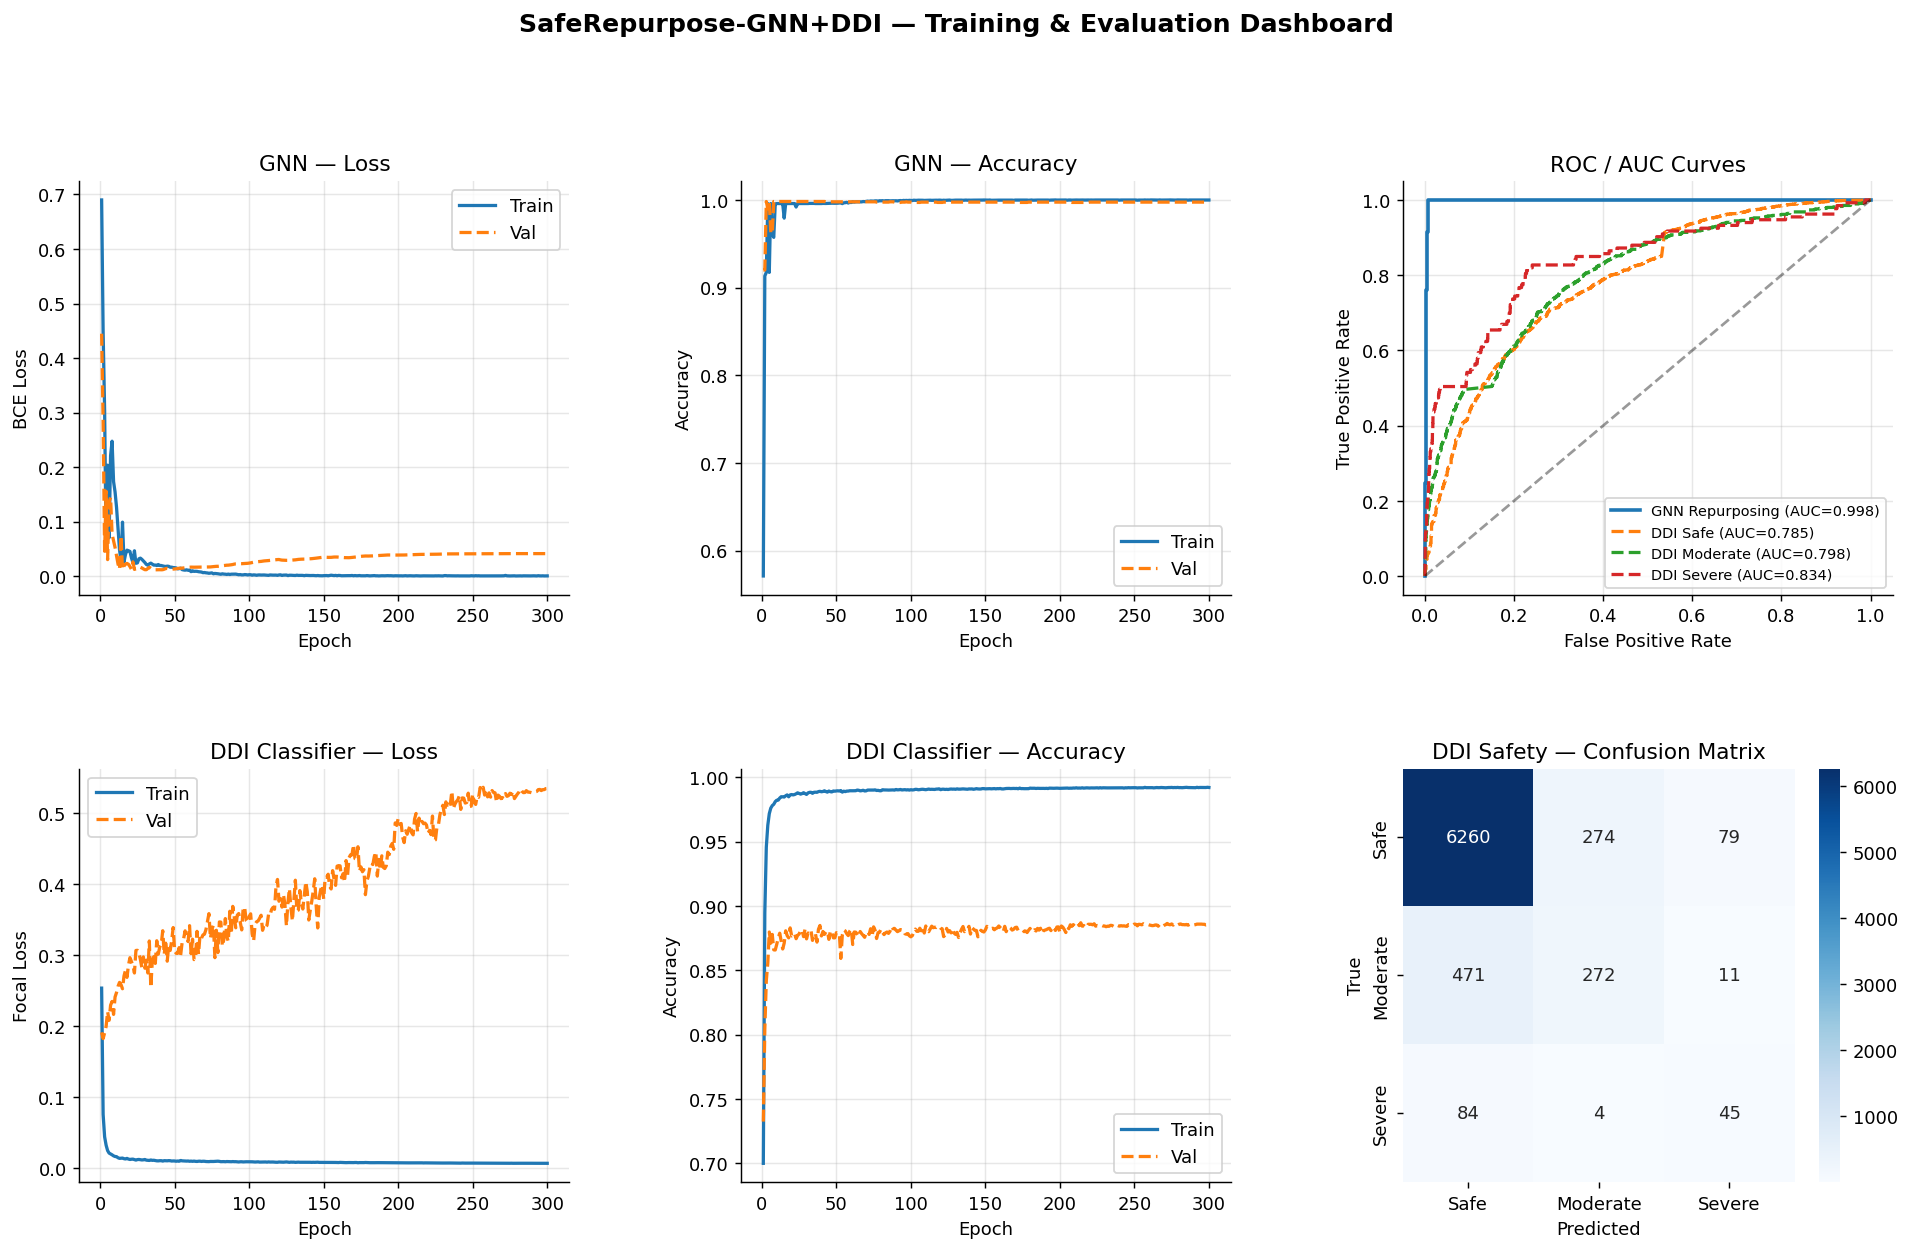

✅ Dashboard saved → outputs/full_training_dashboard.png

✅ Metrics saved → outputs/metrics.json
{
  "model": "SafeRepurpose-GNN+DDI",
  "gnn_auroc": 0.9976,
  "gnn_auprc": 0.9959,
  "gnn_f1": 0.9965,
  "ddi_test_acc": 0.8769,
  "ddi_macro_f1": 0.5618,
  "gnn_best_val_acc": 0.9979,
  "ddi_best_val_acc": 0.5892
}


In [15]:
# ═══════════════════════════════════════════════════════════
# CELL 14 — Unified Metrics + All Plots  [FIXED v4]
# Fixes vs previous version:
#   - Reads all_severity_names from Cell 12 (no hardcoded list)
#   - best_ddi / macro_f1_ddi now set by Cell 12 → no NameError
#   - DDI report uses tuned threshold preds (te_preds) not argmax
#   - ROC curve handles any number of DDI classes dynamically
# ═══════════════════════════════════════════════════════════
%matplotlib inline
import torch, torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import json
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})

# ── 1. GNN repurposing metrics ─────────────────────────────
model.eval()
with torch.no_grad():
    te_logits,_,_ = model(drug_x, disease_x, treats_ei, test_ei)
    te_probs = torch.sigmoid(te_logits).cpu().numpy()
    te_preds_gnn = (te_probs > 0.5).astype(int)
    te_true  = test_y.cpu().numpy()

auroc = roc_auc_score(te_true, te_probs)
auprc = average_precision_score(te_true, te_probs)
f1    = f1_score(te_true, te_preds_gnn)

print('='*55)
print('  GNN REPURPOSING — IEEE Benchmark Metrics')
print('='*55)
print(f'  AUROC : {auroc:.4f}')
print(f'  AUPRC : {auprc:.4f}')
print(f'  F1    : {f1:.4f}')

# ── 2. DDI classifier metrics ──────────────────────────────
# all_severity_names, te_preds, te_true_np set by Cell 12
# te_preds already has tuned Severe threshold applied
ddi_model.eval()
with torch.no_grad():
    te_ddi_probs = torch.softmax(ddi_model(te_x), dim=1).cpu().numpy()

te_ddi_true  = te_true_np        # from Cell 12
te_ddi_preds = te_preds          # threshold-tuned preds from Cell 12

unique_ddi_labels = sorted(np.unique(te_ddi_true).tolist())
display_ddi_names = [all_severity_names[i] for i in unique_ddi_labels]

print()
print('='*55)
print('  DDI SAFETY CLASSIFIER — Classification Report')
print('='*55)
print(classification_report(te_ddi_true, te_ddi_preds,
      labels=unique_ddi_labels, target_names=display_ddi_names,
      zero_division=0))

# ── 3. Build dashboard: 2 rows × 3 cols ────────────────────
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

ax_gloss = fig.add_subplot(gs[0, 0])
ax_gacc  = fig.add_subplot(gs[0, 1])
ax_roc   = fig.add_subplot(gs[0, 2])
ax_dloss = fig.add_subplot(gs[1, 0])
ax_dacc  = fig.add_subplot(gs[1, 1])
ax_cm    = fig.add_subplot(gs[1, 2])

epochs_g = range(1, len(gnn_train_losses) + 1)
epochs_d = range(1, len(ddi_train_losses) + 1)

# ── GNN loss ───────────────────────────────────────────────
ax_gloss.plot(epochs_g, gnn_train_losses, label='Train', linewidth=1.8)
ax_gloss.plot(epochs_g, gnn_val_losses,   label='Val',
              linewidth=1.8, linestyle='--')
ax_gloss.set_title('GNN — Loss')
ax_gloss.set_xlabel('Epoch'); ax_gloss.set_ylabel('BCE Loss')
ax_gloss.legend(); ax_gloss.grid(True, alpha=0.3)

# ── GNN accuracy ───────────────────────────────────────────
ax_gacc.plot(epochs_g, gnn_train_accs, label='Train', linewidth=1.8)
ax_gacc.plot(epochs_g, gnn_val_accs,   label='Val',
             linewidth=1.8, linestyle='--')
ax_gacc.set_title('GNN — Accuracy')
ax_gacc.set_xlabel('Epoch'); ax_gacc.set_ylabel('Accuracy')
ax_gacc.legend(); ax_gacc.grid(True, alpha=0.3)

# ── ROC / AUC ──────────────────────────────────────────────
fpr_gnn, tpr_gnn, _ = roc_curve(te_true, te_probs)
ax_roc.plot(fpr_gnn, tpr_gnn,
            label=f'GNN Repurposing (AUC={auroc:.3f})', linewidth=2)

if len(unique_ddi_labels) == 2:
    # Binary DDI ROC
    pos_idx = unique_ddi_labels[1]
    fpr_i, tpr_i, _ = roc_curve(
        (te_ddi_true == pos_idx).astype(int),
        te_ddi_probs[:, pos_idx])
    auc_i = auc(fpr_i, tpr_i)
    ax_roc.plot(fpr_i, tpr_i,
                label=f'DDI {all_severity_names[pos_idx]} vs Rest '
                      f'(AUC={auc_i:.3f})',
                linewidth=2, linestyle='--')
else:
    # Multi-class DDI ROC — one curve per class
    te_ddi_bin = label_binarize(te_ddi_true, classes=unique_ddi_labels)
    for col_i, lidx in enumerate(unique_ddi_labels):
        prob_col = te_ddi_probs[:, lidx] if lidx < te_ddi_probs.shape[1] \
                   else te_ddi_probs[:, -1]
        fpr_i, tpr_i, _ = roc_curve(te_ddi_bin[:, col_i], prob_col)
        auc_i = auc(fpr_i, tpr_i)
        ax_roc.plot(fpr_i, tpr_i,
                    label=f'DDI {all_severity_names[lidx]} '
                          f'(AUC={auc_i:.3f})',
                    linewidth=1.8, linestyle='--')

ax_roc.plot([0,1],[0,1], 'k--', alpha=0.4)
ax_roc.set_title('ROC / AUC Curves')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.legend(loc='lower right', fontsize=8)
ax_roc.grid(True, alpha=0.3)

# ── DDI loss ───────────────────────────────────────────────
ax_dloss.plot(epochs_d, ddi_train_losses, label='Train', linewidth=1.8)
ax_dloss.plot(epochs_d, ddi_val_losses,   label='Val',
              linewidth=1.8, linestyle='--')
ax_dloss.set_title('DDI Classifier — Loss')
ax_dloss.set_xlabel('Epoch'); ax_dloss.set_ylabel('Focal Loss')
ax_dloss.legend(); ax_dloss.grid(True, alpha=0.3)

# ── DDI accuracy ───────────────────────────────────────────
ax_dacc.plot(epochs_d, ddi_train_accs, label='Train', linewidth=1.8)
ax_dacc.plot(epochs_d, ddi_val_accs,   label='Val',
             linewidth=1.8, linestyle='--')
ax_dacc.set_title('DDI Classifier — Accuracy')
ax_dacc.set_xlabel('Epoch'); ax_dacc.set_ylabel('Accuracy')
ax_dacc.legend(); ax_dacc.grid(True, alpha=0.3)

# ── Confusion matrix ───────────────────────────────────────
cm = confusion_matrix(te_ddi_true, te_ddi_preds,
                      labels=unique_ddi_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=display_ddi_names,
            yticklabels=display_ddi_names,
            ax=ax_cm)
ax_cm.set_xlabel('Predicted'); ax_cm.set_ylabel('True')
ax_cm.set_title('DDI Safety — Confusion Matrix')

fig.suptitle('SafeRepurpose-GNN+DDI — Training & Evaluation Dashboard',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig(f'{OUT}/full_training_dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Dashboard saved → outputs/full_training_dashboard.png')

# ── 4. Save IEEE metrics JSON ──────────────────────────────
# best_ddi and macro_f1_ddi are set at end of Cell 12
metrics = {
    'model'           : 'SafeRepurpose-GNN+DDI',
    'gnn_auroc'       : round(auroc,        4),
    'gnn_auprc'       : round(auprc,        4),
    'gnn_f1'          : round(f1,           4),
    'ddi_test_acc'    : round(te_a,         4),
    'ddi_macro_f1'    : round(macro_f1_ddi, 4),
    'gnn_best_val_acc': round(best_val,     4),
    'ddi_best_val_acc': round(best_ddi,     4),
}
with open(f'{OUT}/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('\n✅ Metrics saved → outputs/metrics.json')
print(json.dumps(metrics, indent=2))